# Progetto BISF 3 aprile 2025
# Enrico Zhou mat. 899736

In [3]:
# importazione librerie

In [52]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import pandas_datareader.data as web
import numpy as np
import backtrader as bt
import matplotlib.pyplot as plt
import scipy as sp
import datetime as dt
import matplotlib as mpl
import seaborn as sns
import importlib
import statsmodels.api as sm
import statsmodels.formula.api as smf
import math
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import os
from datetime import datetime
import scipy.optimize as sco
import cvxpy as cp
from curl_cffi import requests


%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [53]:
sns.set_style("whitegrid")
plt.rcParams['axes.grid'] = True  # Griglia globale
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

In [55]:
pd.options.mode.copy_on_write = True

# 1. Sommario dei dati utilizzati

In [59]:
# a. Breve descrizione di ciascun titolo o ETF selezionato e motivazione della scelta
# MSFT, NVDA settore della Tecnologia, chip(semiconduttori)
# LLY, UNH settore dell Assistenza sanitaria
# JPM, GS settore della Finanza

# Microsoft Corporation (MSFT): IT, cloud computing, AI, software
# Nvidia (NVDA): AI e GPU
# JPMorgan Chase (JPM): Banca sistemica
# Eli Lilly (LLY): Farmaci per obesità (Zepbound) e diabete (Mounjaro)
# UnitedHealth Group (UNH): Leader assicurativo sanitario
# Goldman Sachs (GS): Investment banking

stk_tickers = ['MSFT', 'NVDA', 'LLY', 'JPM', 'UNH', 'GS']

# Percorso della cartella dove salvare
folder_path = "Desktop/Grafici BISF" # nome cartella: str
file_name = "" # nome file.jpeg: str
full_path = os.path.join(folder_path, file_name)
# Salvataggio del grafico
# plt.savefig(full_path)

# curl_cffi library
# mi da errore con yfinance.download quindi prova a impersonificare come se fosse eseguito da browser invece che da codice python sul server
session = requests.Session(impersonate="chrome")

In [61]:
# periodo di acquisizione dati
start_date = '2014-05-31'
end_date = '2024-05-31'

In [65]:
# scaricamento dei dati
df = yf.download(stk_tickers, start_date, end_date, session=session)

[*********************100%***********************]  6 of 6 completed


In [73]:
df_close = df['Close']

In [75]:
df_close.head()

Ticker,GS,JPM,LLY,MSFT,NVDA,UNH
Date,,,,,,
2014-06-02,129.880310,40.952988,48.341053,34.521275,0.450631,67.109688
2014-06-03,131.316879,41.137966,48.227287,34.098137,0.448728,67.455917
2014-06-04,131.795715,41.197159,48.121651,34.123524,0.449204,67.987938
2014-06-05,131.949905,41.900063,48.414188,34.876736,0.451107,67.388367
2014-06-06,134.879807,42.151630,48.454811,35.105244,0.452773,67.498131


In [22]:
# funzione salvataggio grafico
def salva_grafico(nome_file: str, nome_folder: str= "Desktop/Grafici BISF"):
    plt.savefig(os.path.join(nome_folder, f'{nome_file}.jpg'))

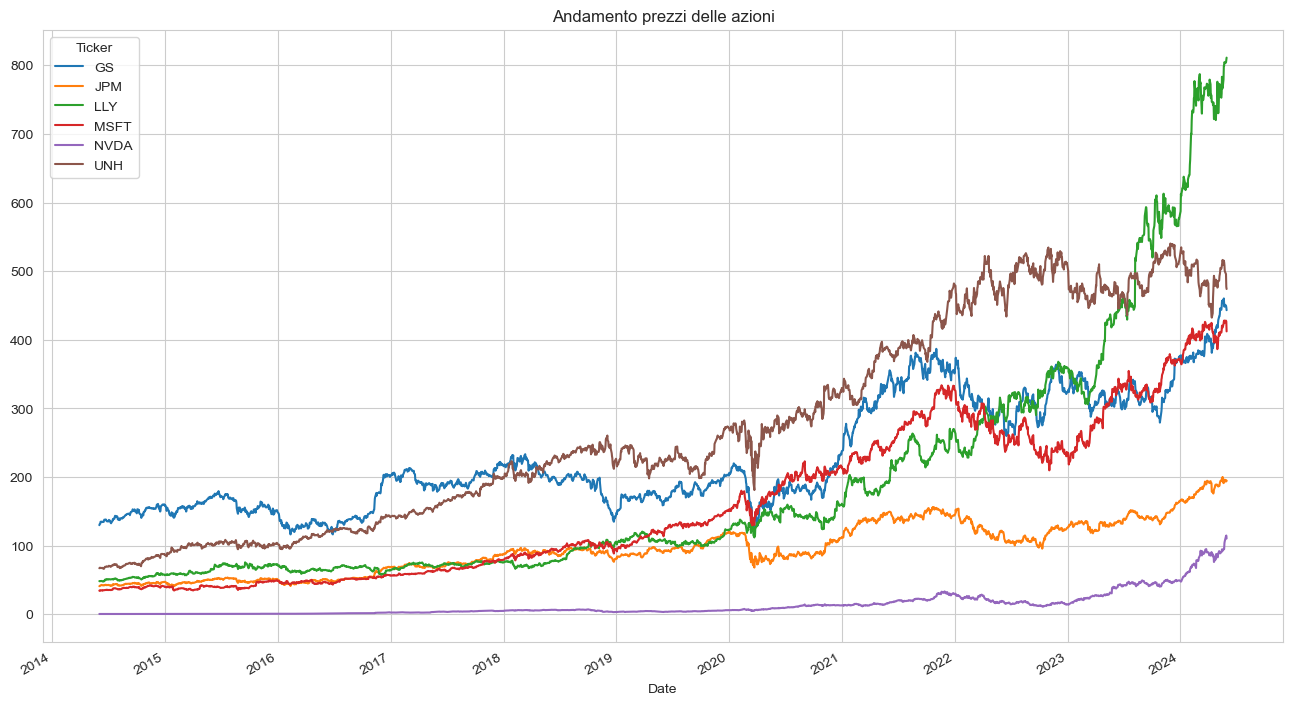

In [77]:
# grafico prezzi delle azioni
df_close.plot(title="Andamento prezzi delle azioni", figsize=(16,9))
# salva_grafico('prezzo_titoli')
plt.show();

In [328]:
df_close.head()

Ticker,GS,JPM,LLY,MSFT,NVDA,UNH
Date,,,,,,
2014-06-02,129.880341,40.953003,48.341057,34.521286,0.450631,67.109680
2014-06-03,131.316895,41.137978,48.227299,34.098122,0.448728,67.455956
2014-06-04,131.795670,41.197170,48.121647,34.123528,0.449204,67.987923
2014-06-05,131.949951,41.900066,48.414188,34.876743,0.451107,67.388390
2014-06-06,134.879807,42.151619,48.454830,35.105247,0.452773,67.498138


In [79]:
# divisione in categorie
df_close_tech = df_close[['MSFT', 'NVDA']]
df_close_finance = df_close[['GS', 'JPM']]
df_close_healthcare = df_close[['LLY', 'UNH']]

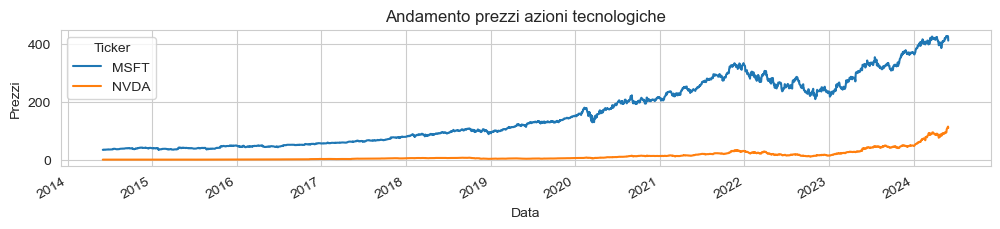

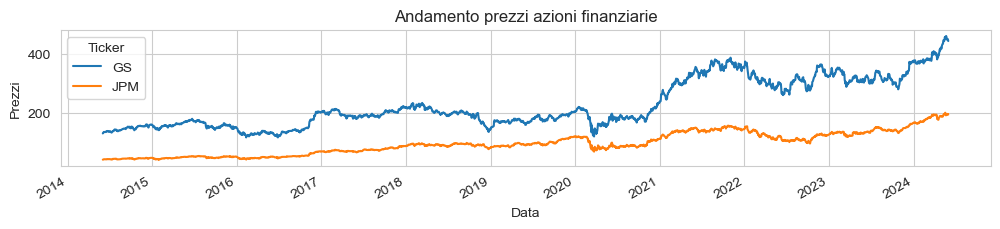

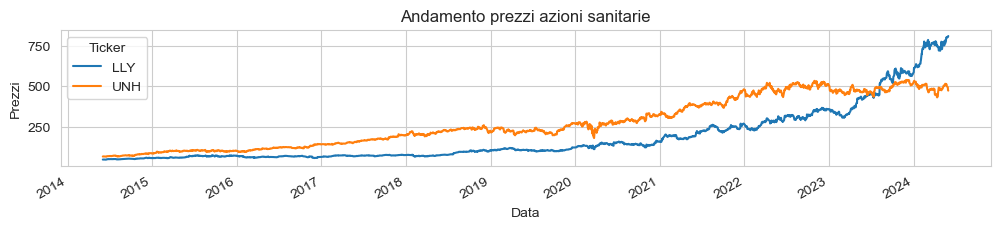

In [81]:
df_close_tech.plot(title="Andamento prezzi azioni tecnologiche", figsize=(12, 2), xlabel="Data", ylabel="Prezzi")
# salva_grafico('Andamento prezzi azione tecnologiche')
df_close_finance.plot(title="Andamento prezzi azioni finanziarie", figsize=(12, 2), xlabel="Data", ylabel="Prezzi")
# salva_grafico('Andamento prezzi azione finanziarie')
df_close_healthcare.plot(title="Andamento prezzi azioni sanitarie", figsize=(12, 2), xlabel="Data", ylabel="Prezzi");
# salva_grafico('Andamento prezzi azione sanitarie')
plt.show();

# 2. Statistiche descrittive

In [84]:
# a.
# Calcolare il rendimento cumulato nel periodo
prezzo_iniziale = df_close.iloc[0].copy()
prezzo_finale = df_close.iloc[-1].copy()
rendimento_cumulato = (prezzo_finale / prezzo_iniziale - 1) * 100
print(f"Rendimento cumulato: {rendimento_cumulato:}%")


Rendimento cumulato: Ticker
GS        241.220437
JPM       375.696516
LLY      1578.033149
MSFT     1094.250274
NVDA    24413.088747
UNH       606.408551
dtype: float64%


In [86]:
# Calcare il Rendimento Composto medio annuo nel periodo
anni = 10
rendimento_composto_annuo = ((prezzo_finale / prezzo_iniziale) ** (1/anni) - 1) * 100
print(f"Rendimento composto annuo: {rendimento_composto_annuo:}%")

Rendimento composto annuo: Ticker
GS      13.058574
JPM     16.878061
LLY     32.580622
MSFT    28.147322
NVDA    73.356370
UNH     21.592166
dtype: float64%


In [88]:
# b.
# creazione dataframe per rendimenti semplici
rs = pd.DataFrame()
# Rendimenti semplici per ogni azione
for stk in df_close:
    rs[stk] = df_close[stk].pct_change().dropna()
# Rendimenti semplici per ogni settore
rs_tech = rs[['MSFT', 'NVDA']]
rs_finance = rs[['GS', 'JPM']]
rs_healthcare = rs[['LLY', 'UNH']]

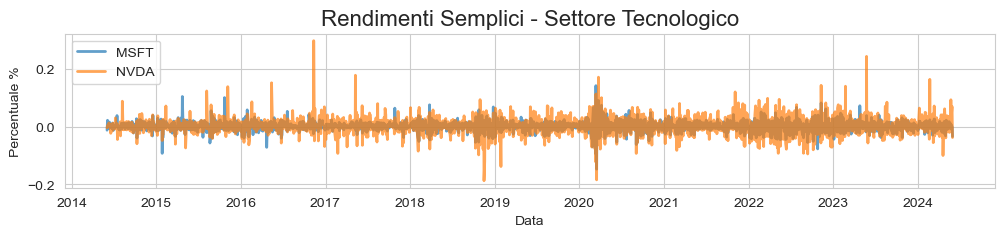

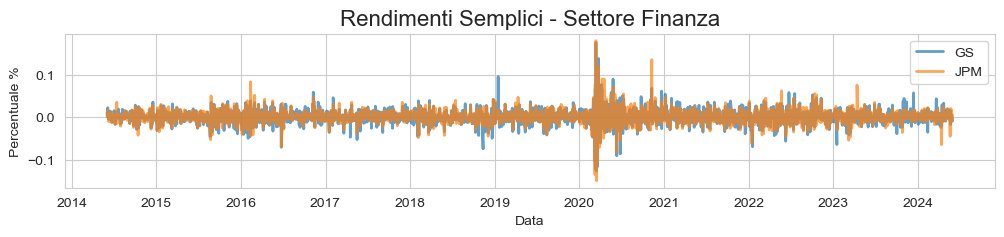

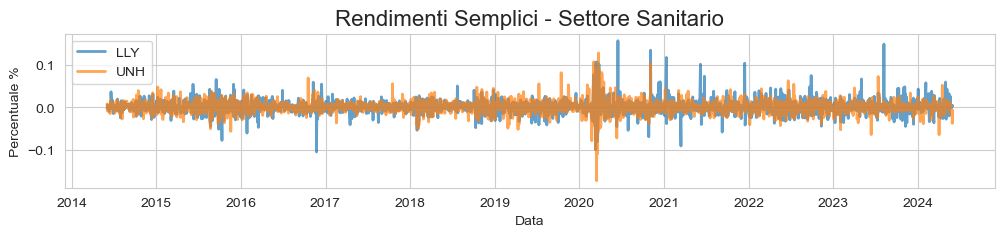

In [90]:
def rs_categoria(cat, titolo):
    # visualizzarli in un grafico;
    plt.figure(figsize=(12, 2))
    for col in cat.columns:
        plt.plot(cat.index, cat[col], label=col, alpha=0.7, linewidth=2)
    plt.title(f"Rendimenti Semplici - Settore {titolo}", fontsize=16)
    plt.xlabel("Data")
    plt.ylabel("Percentuale %")
    plt.legend()
    plt.grid(True)
    # salva_grafico('Rendimenti Semplici - Settore Tecnologico')
    plt.show()
rs_categoria(rs_tech, 'Tecnologico')
rs_categoria(rs_finance, 'Finanza')
rs_categoria(rs_healthcare, 'Sanitario')

In [91]:
# b.
# creazione di un nuovo dataframe per rendimenti logaritmici
rlog = pd.DataFrame()
# Rendimenti logaritmici per ogni azione
for stk in df_close:
    rlog[f'{stk}'] = np.log(df_close[stk] / df_close[stk].shift(1)).dropna()
# Rendimenti logaritmici per ogni settore
rlog_tech = rlog[['MSFT', 'NVDA']]
rlog_finance = rlog[['GS', 'JPM']]
rlog_healthcare = rlog[['LLY', 'UNH']]


# trasformazione da rendimenti logaritmici giornalieri a mensili
rlog_mensili = (1 + rlog).resample('ME').prod() - 1

In [94]:
rlog.head()

,GS,JPM,LLY,MSFT,NVDA,UNH
Date,,,,,,
2014-06-03,0.011000,0.004507,-0.002356,-0.012333,-0.004233,0.005146
2014-06-04,0.003640,0.001438,-0.002193,0.000744,0.001060,0.007856
2014-06-05,0.001169,0.016918,0.006061,0.021833,0.004228,-0.008858
2014-06-06,0.021962,0.005986,0.000839,0.006531,0.003685,0.001628
2014-06-09,-0.001144,0.007868,0.001843,-0.005075,0.001050,-0.002129


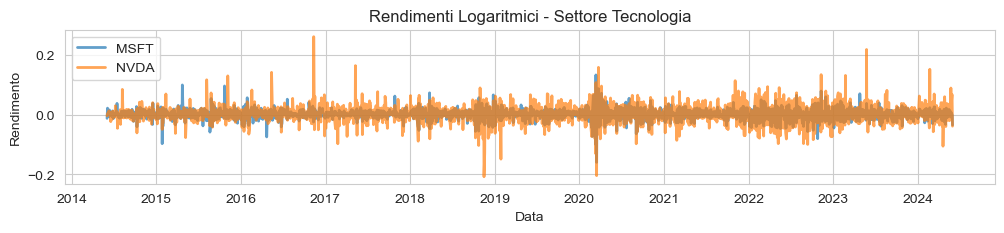

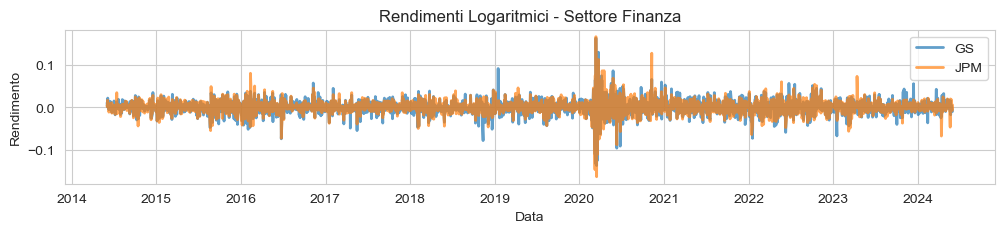

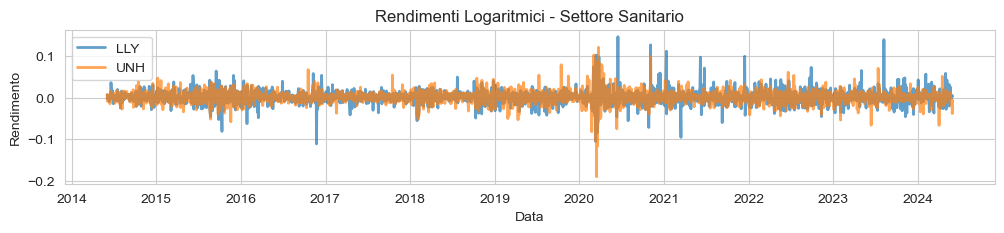

In [96]:
def rlog_categoria(cat, titolo):
    # visualizzarli in un grafico;
    plt.figure(figsize=(12, 2))
    for col in cat.columns:
        plt.plot(cat.index, cat[col], label=col, alpha=0.7, linewidth=2)
    plt.title(f"Rendimenti Logaritmici - Settore {titolo}")
    plt.xlabel("Data")
    plt.ylabel("Rendimento")
    plt.legend()
    plt.grid(True)
    plt.show()
rlog_categoria(rlog_tech, 'Tecnologia')
rlog_categoria(rlog_finance, 'Finanza')
rlog_categoria(rlog_healthcare, 'Sanitario')

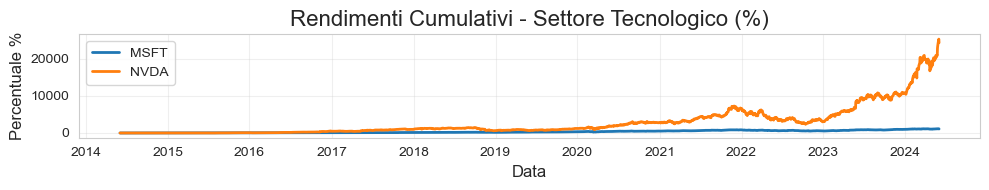

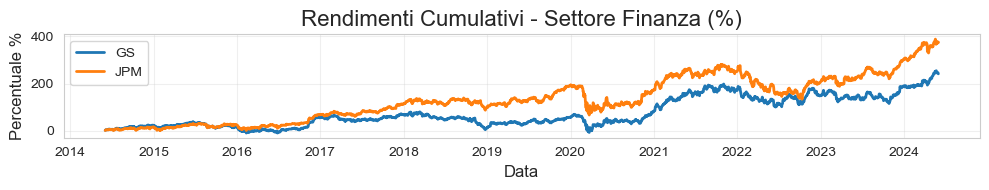

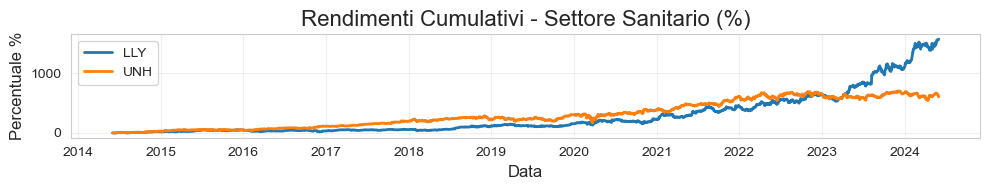

In [98]:
# Calcola i rendimenti cumulativi
cumulative_returns = (1 + rs).cumprod() - 1

# Calcola i rendimenti cumulativi
rcum = (1 + rs).cumprod() - 1

rcum_tech = rcum[['MSFT', 'NVDA']]
rcum_finance = rcum[['GS', 'JPM']]
rcum_healthcare = rcum[['LLY', 'UNH']]

def grafico_rcum_cat(df_cat, cat):

    # Imposta lo stile del grafico
    plt.figure(figsize=(10, 2))
    
    # Plot dei rendimenti cumulativi
    plt.plot(rcum.index, df_cat * 100, label=df_cat.columns, linewidth=2)
    
    # Aggiunta di titoli e legenda
    plt.title(f'Rendimenti Cumulativi - Settore {cat} (%)', fontsize=16)
    plt.xlabel('Data', fontsize=12)
    plt.ylabel('Percentuale %', fontsize=12)
    plt.legend(fontsize=10)
    
    # Griglia e formattazione
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Mostra il grafico
    plt.show()

# Esempio di utilizzo:
# stk_tickers = ['MSFT', 'NVDA', 'LLY', 'JPM', 'UNH', 'GS']
# cum_returns = plot_cumulative_returns(df_close, stk_tickers)
grafico_rcum_cat(rcum_tech, 'Tecnologico')
grafico_rcum_cat(rcum_finance, 'Finanza')
grafico_rcum_cat(rcum_healthcare, 'Sanitario')

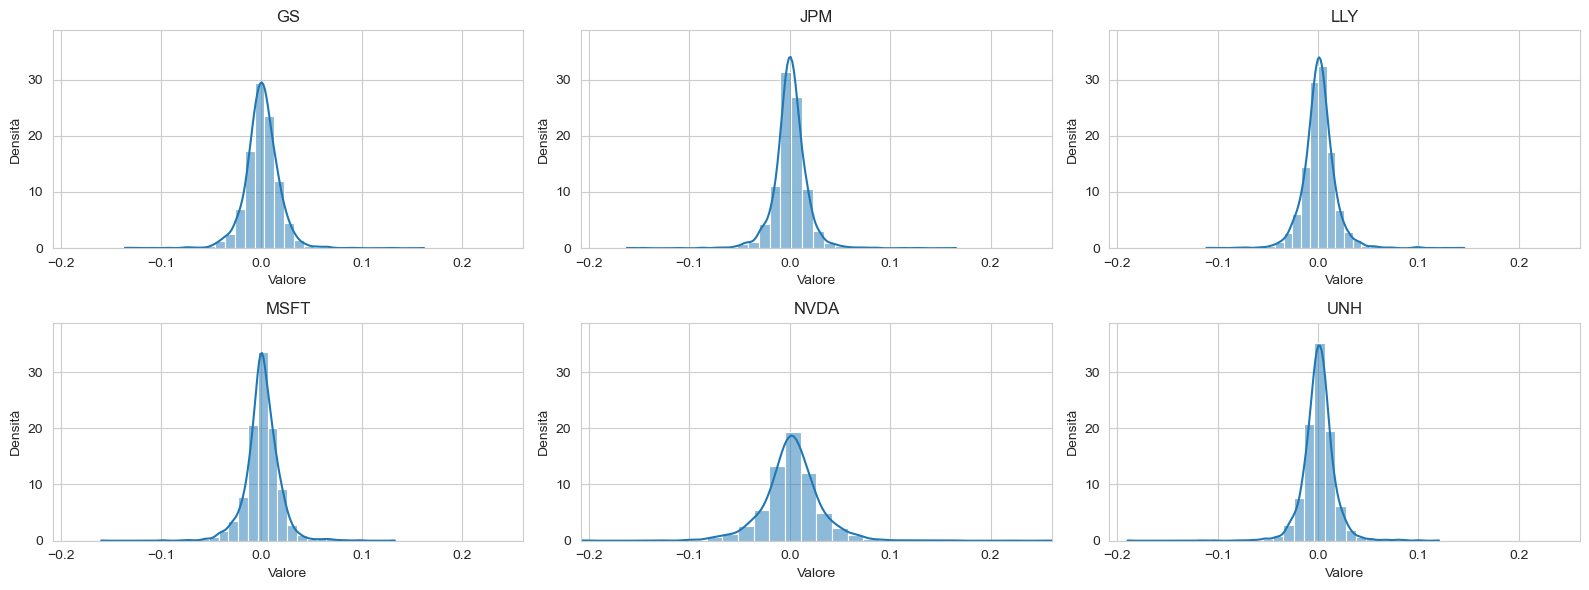

In [875]:
# creazione grafici istogramma e kernel density
def istogramma_kernel(df):
    plt.figure(figsize=(16,6))
    x_min = min(df[stk].min() for stk in df.columns)
    x_max = max(df[stk].max() for stk in df.columns)
    y_max = max(
        np.max(np.histogram(df[stk], bins=30, density=True)[0]) 
        for stk in df.columns
    ) * 1.1
    
    for i, stk in enumerate(df.columns, 1):
        plt.subplot(2, 3, i)
        sns.histplot(df[stk], bins=30, kde=True, stat='density')
        plt.title(stk)
        plt.xlabel("Valore")
        plt.ylabel("Densità")
        # Imposta gli stessi limiti per tutti i grafici
        plt.xlim(x_min, x_max)
        plt.ylim(0, y_max)
        
    plt.tight_layout()
    plt.show()

istogramma_kernel(rlog)

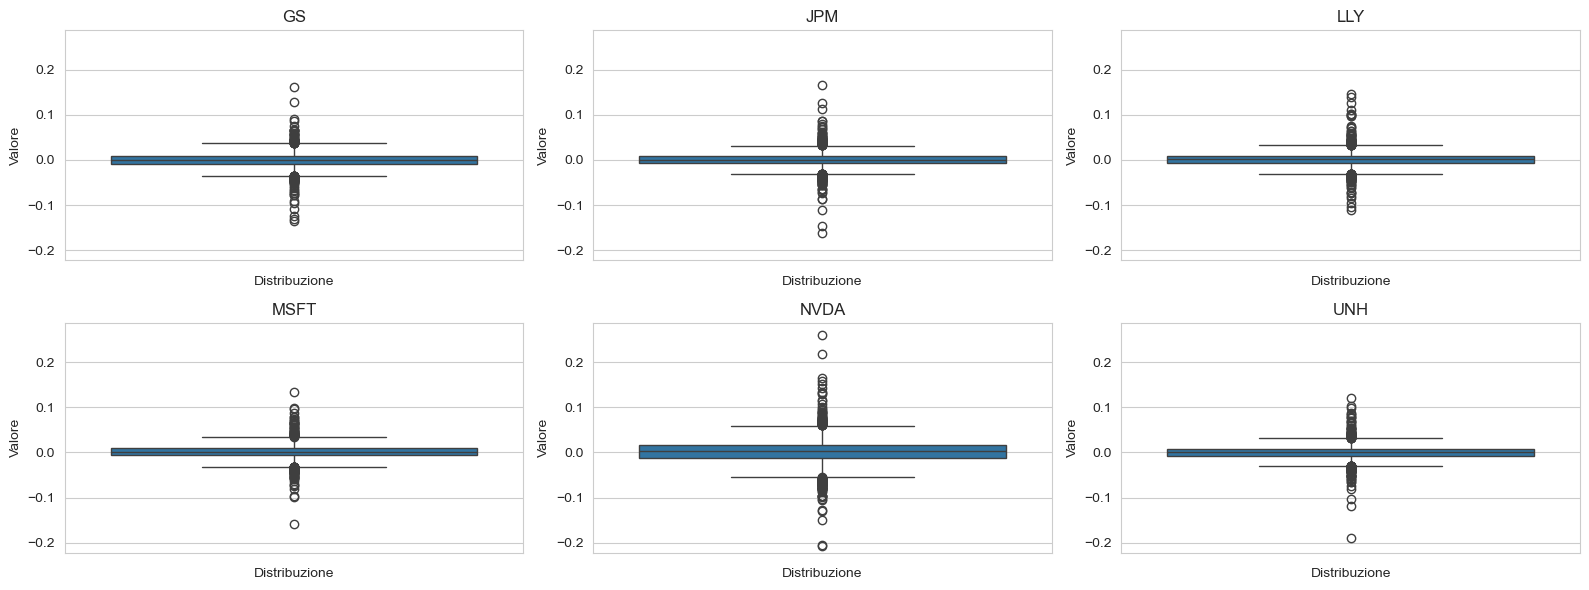

In [877]:
# creazione grafici istogramma e kernel density
def boxplot(df):
    plt.figure(figsize=(16,6))
    y_min = max(np.min(df[stk]) for stk in df.columns) * 2
    y_max = max(np.max(df[stk]) for stk in df.columns) * 1.1
    
    for i, stk in enumerate(df.columns, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(df[stk], patch_artist=True)
        plt.title(stk)
        plt.xlabel("Distribuzione")
        plt.ylabel("Valore")
        plt.ylim(y_min, y_max)
        
    plt.tight_layout()
    plt.show()

boxplot(rlog)

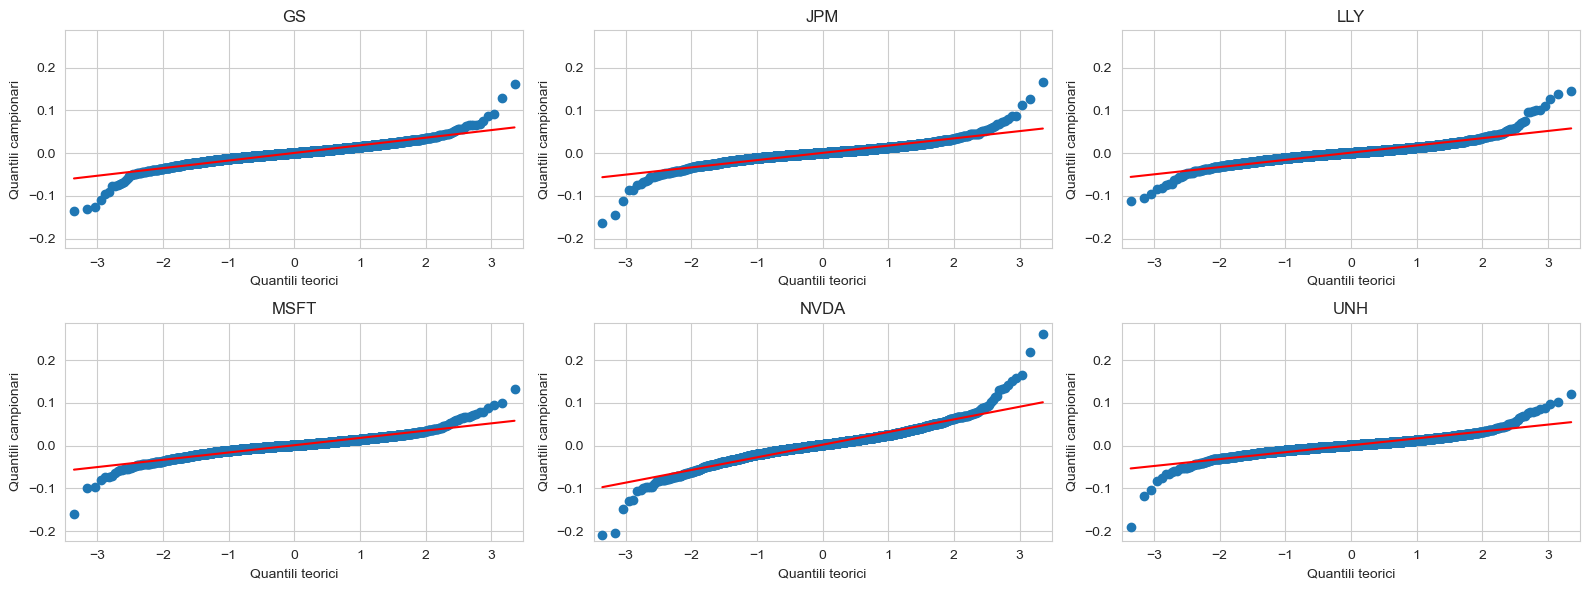

In [883]:
# creazione grafici istogramma e kernel density
def qqplot(df):
    plt.figure(figsize=(16,6))
    y_min = max(np.min(df[stk]) for stk in df.columns) * 2
    y_max = max(np.max(df[stk]) for stk in df.columns) * 1.1
    
    for i, stk in enumerate(df.columns, 1):
        axsis = plt.subplot(2, 3, i)
        sm.qqplot(df[stk], line='s', ax=axsis)
        plt.title(stk)
        axsis.set_xlabel("Quantili teorici")
        axsis.set_ylabel("Quantili campionari")
        plt.ylim(y_min, y_max)

    plt.tight_layout()
    plt.show();

qqplot(rlog)

In [921]:
# d. Creare grafici diagnostici a 3 sezioni (istogramma e kernel density, boxplot, qq-plot) per ciascuna serie di rendimenti
def grafici_diagnostici(df, stock):
    plt.figure(figsize=(16, 6))
    
    plt.suptitle(f'{stock}',
                y=1.05, fontsize=20, fontweight='bold')
    
    plt.subplot(1, 3, 1)  # 1 righe, 3 colonna, posizione 1
    plt.title('Istogramma e Kernel Density')
    sns.histplot(df[stock], bins=30, kde=True, 
                     stat='density', alpha=0.3, 
                      edgecolor=None,
                     label=stock)
    plt.xlabel("Valore")
    plt.ylabel("Densità")
    
    plt.subplot(1, 3, 2)  # 1 righe, 3 colonne, posizione 2
    plt.title('Boxplot')
    sns.boxplot(df[stock], patch_artist=True)
    plt.xlabel("Distribuzione")
    plt.ylabel("Valore")
    
    axsis = plt.subplot(1, 3, 3)  # 1 righe, 3 colonne, posizione 3
    plt.title('QQPlot')
    sm.qqplot(df[stock], line='s', ax=axsis)
    axsis.set_xlabel("Quantili teorici")
    axsis.set_ylabel("Quantili campionari")
    
    plt.tight_layout()
    # salva_grafico(f'grafici_diagnostici {stock}')
    plt.show();

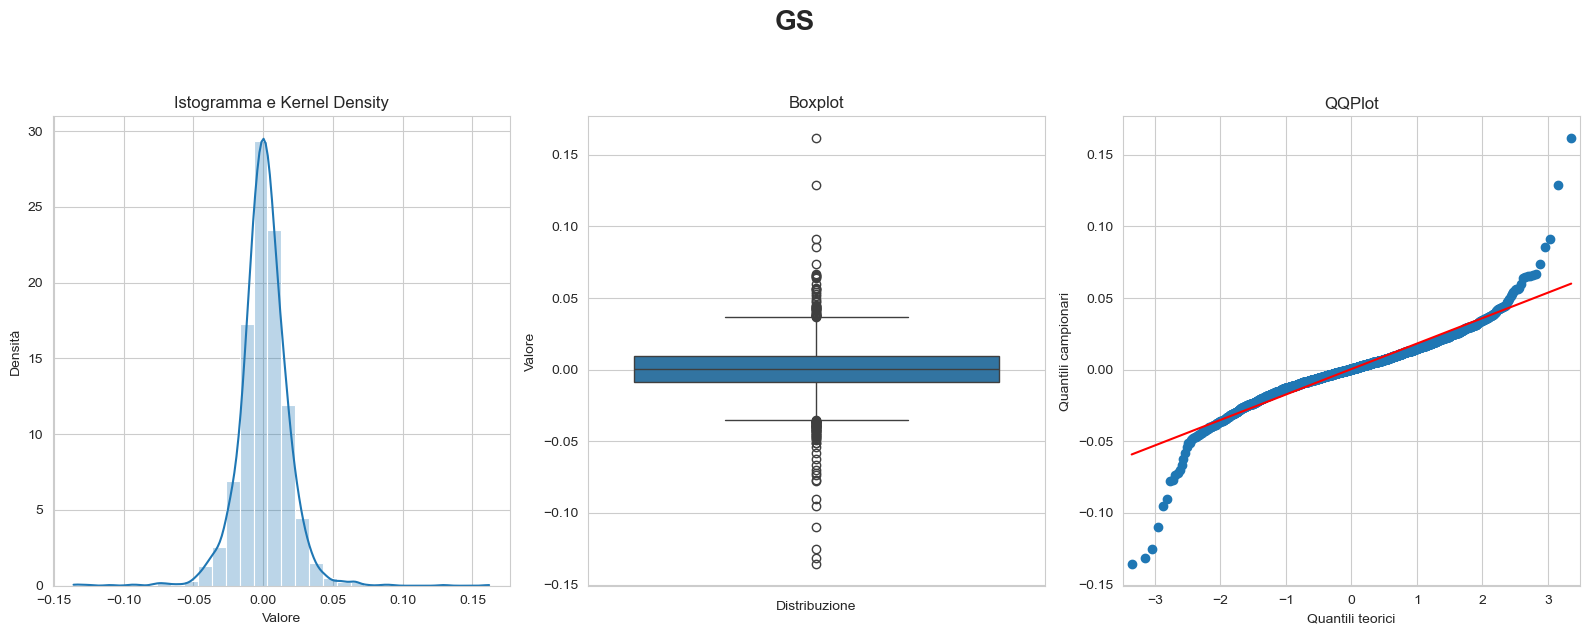

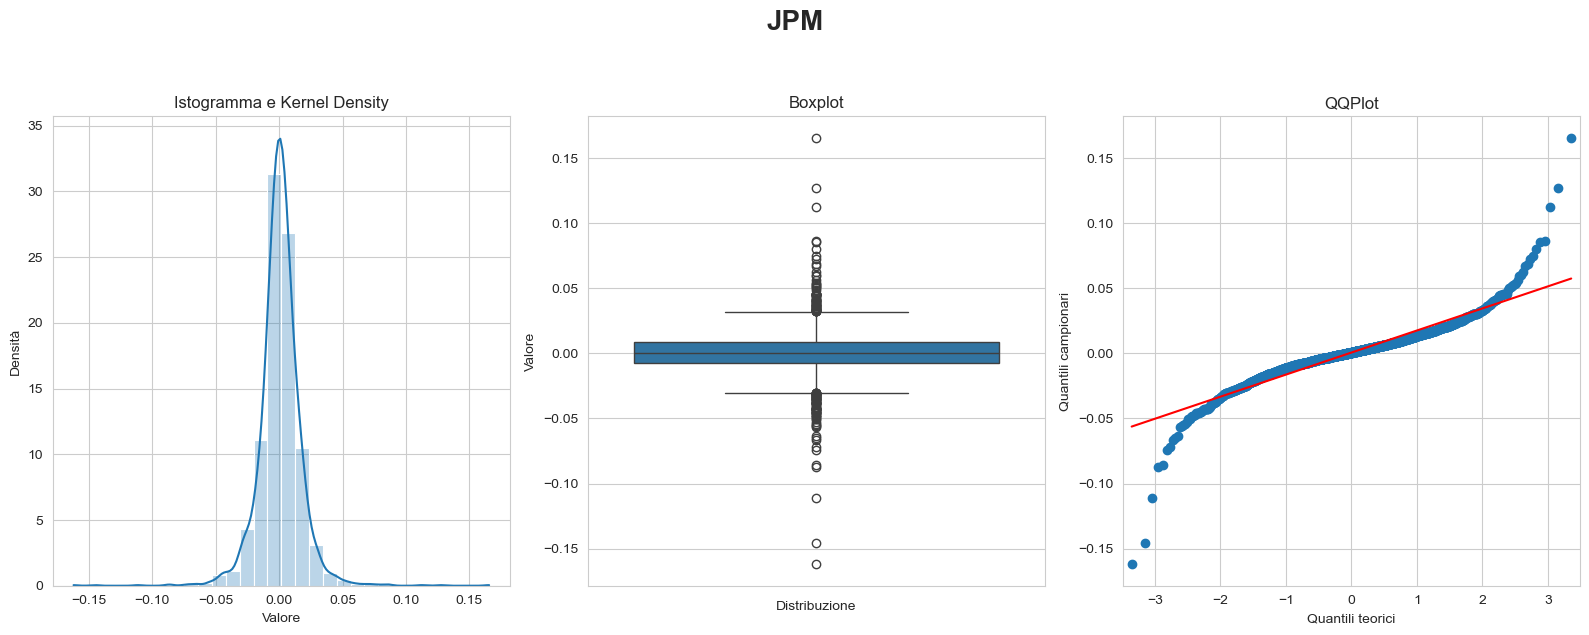

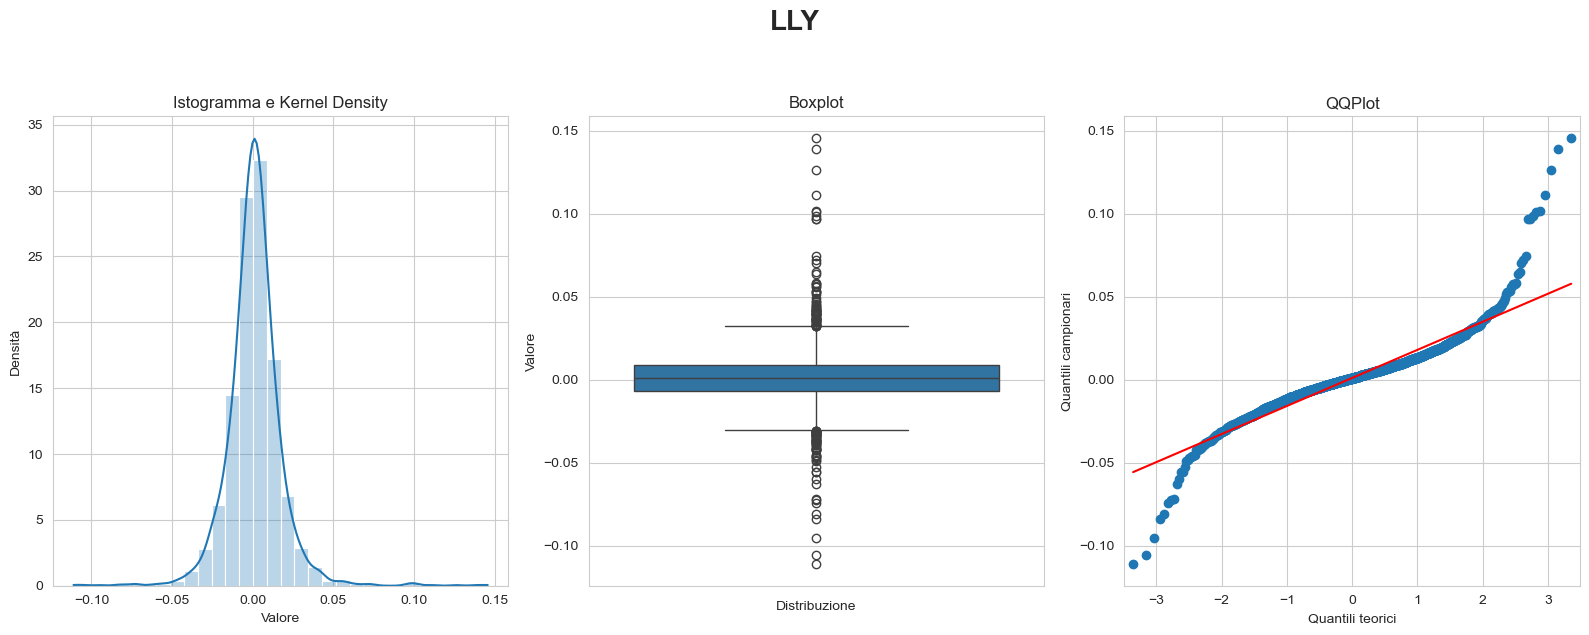

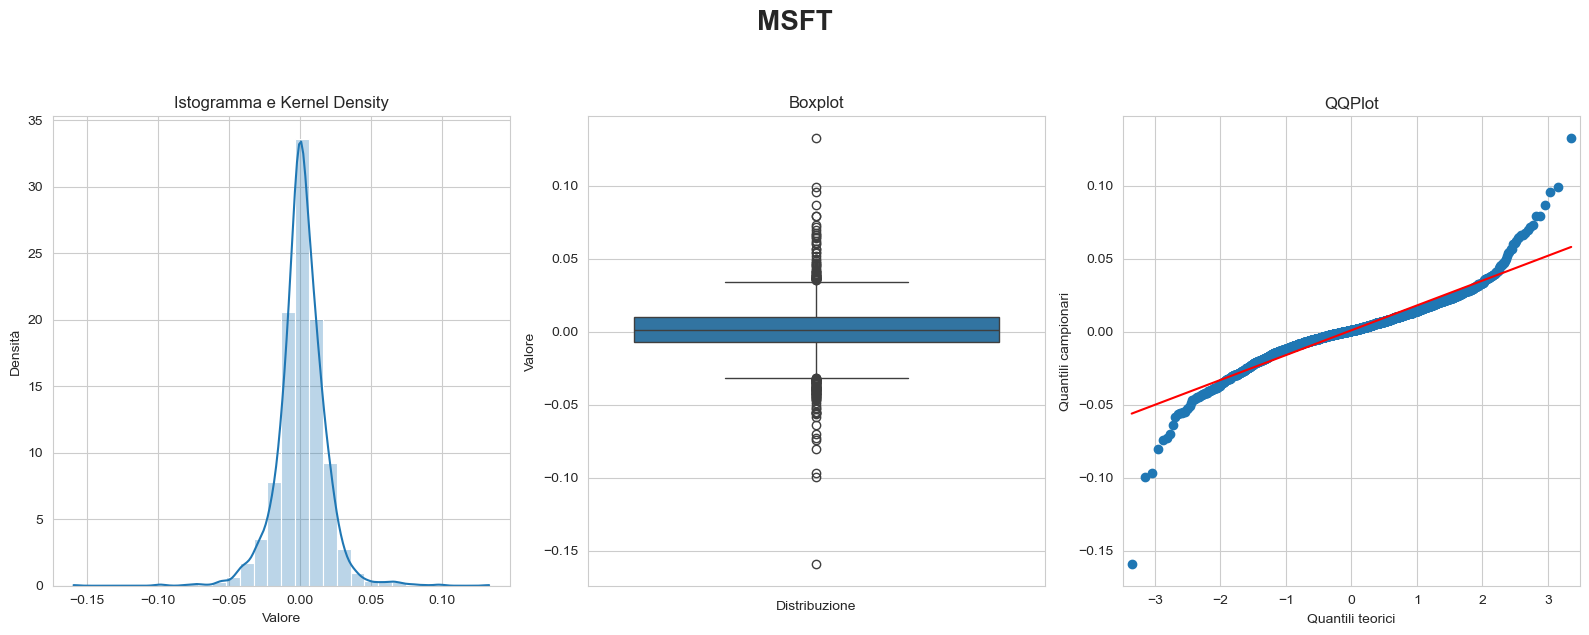

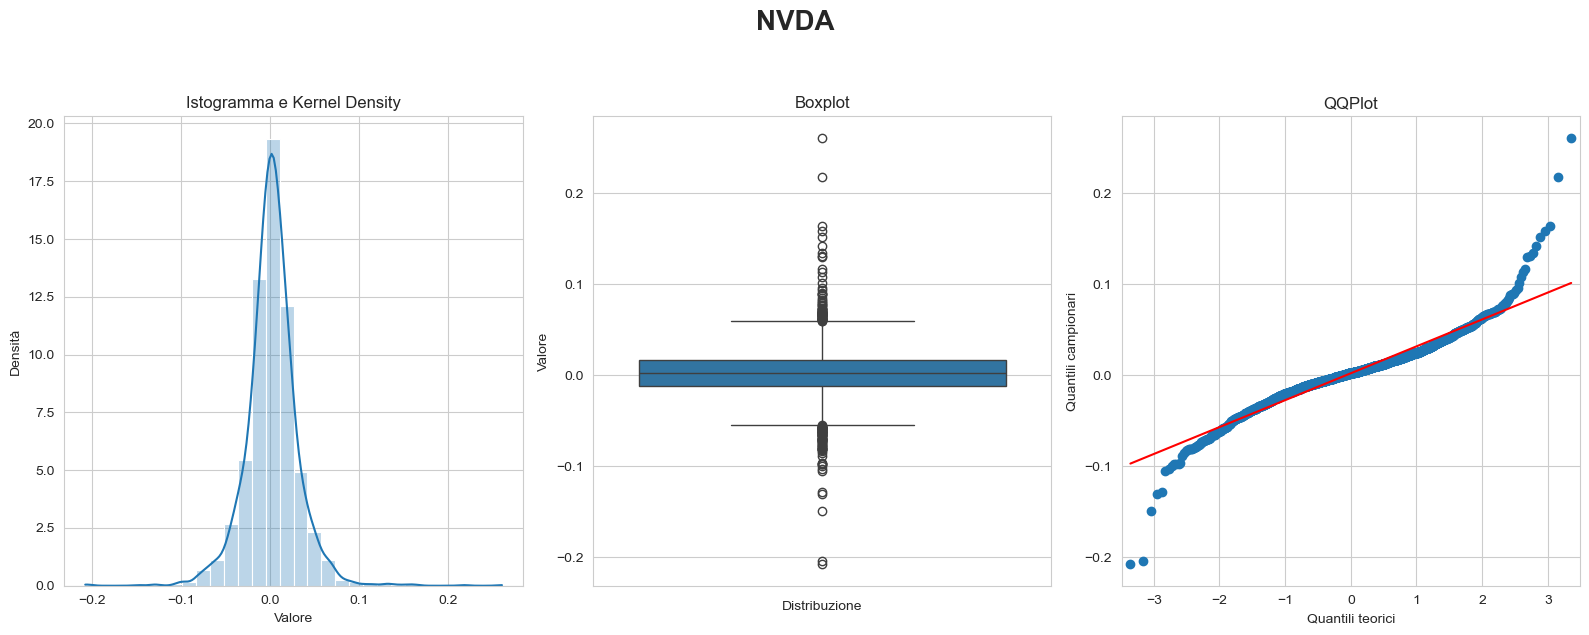

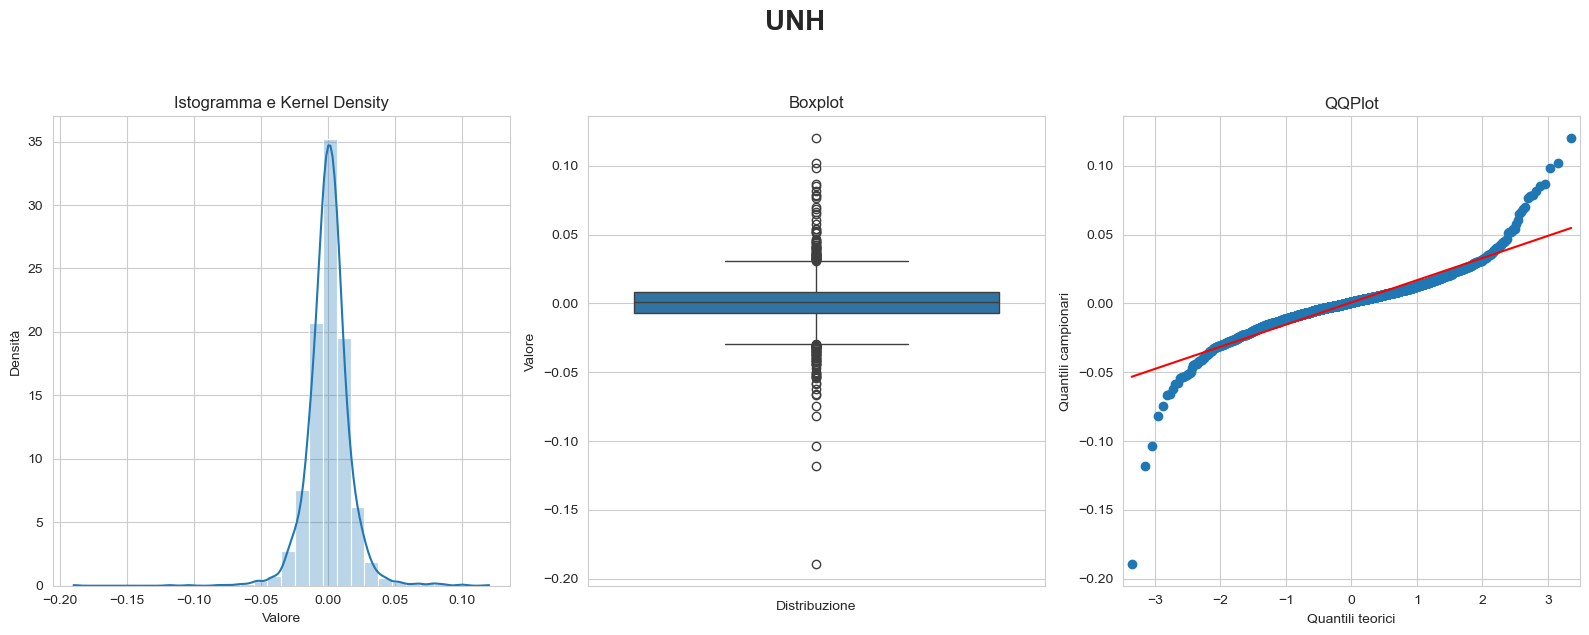

In [923]:
for stk in df_close.columns:
    grafici_diagnostici(rlog, stk)

In [351]:
# e. Calcolare statistiche descrittive univariate annualizzate (media, varianza, deviazione standard, asimmetria, curtosi) per ogni serie di rendimenti
def statistiche_descrittive(df, periodo):
    giorni_di_trading_annui = periodo
    df_stats = pd.DataFrame(index = df.columns)
    # media annua dei rendimenti
    df_stats['Media'] = df.mean() * giorni_di_trading_annui
    # varianza annua dei rendimenti
    df_stats['Varianza'] = df.var() * giorni_di_trading_annui
    # deviazione annua standard dei rendimenti
    df_stats['Deviazione Standard'] = df.std() * np.sqrt(giorni_di_trading_annui)
    # assimetria dei rendimenti
    df_stats['Asimmetria'] = df.skew()
    # curtosi dei rendimenti
    df_stats['Curtosi'] = df.kurtosis()
    return df_stats

In [352]:
statistiche_descrittive(rlog, 252)

,Media,Varianza,Deviazione Standard,Asimmetria,Curtosi
GS,0.122931,0.079660,0.282241,-0.202519,9.576120
JPM,0.156209,0.072424,0.269118,-0.103435,13.771978
LLY,0.282469,0.071980,0.268291,0.739553,10.726891
MSFT,0.248405,0.073070,0.270314,-0.151877,8.174000
NVDA,0.551054,0.220368,0.469433,0.248184,7.631894
UNH,0.195813,0.065520,0.255968,-0.406051,14.367694


In [100]:
# f. Calcolare la matrice di varianze/covarianze e di correlazione dei rendimenti mensili.
# trasformazione da rendimenti giornalieri a rendimenti mensili
rs_mensili = (1 + rs).resample('ME').prod() - 1
# rendimenti_mensili = df_close.resample('ME').last().pct_change().dropna()

In [354]:
rs_mensili.head()

,GS,JPM,LLY,MSFT,NVDA,UNH
Date,,,,,,
2014-06-30,0.046304,0.041012,0.045050,0.022310,-0.021119,0.033525
2014-07-31,0.032430,0.007864,-0.017854,0.035012,-0.056095,-0.008563
2014-08-31,0.039309,0.030865,0.049321,0.059169,0.116345,0.069463
2014-09-30,0.024901,0.013289,0.020296,0.020471,-0.051414,-0.000729
2014-10-31,0.034973,0.010749,0.022822,0.012726,0.059079,0.101565


In [102]:
# Mostra come i rendimenti di due asset si muovono insieme. Valori positivi indicano che i rendimenti tendono a muoversi nella stessa direzione, mentre valori negativi indicano movimenti opposti.
# Matrice di varianza/covarianze
cov_matrix = rs_mensili.cov()
cov_matrix

,GS,JPM,LLY,MSFT,NVDA,UNH
GS,0.006551,0.004789,0.000610,0.002157,0.004013,0.001577
JPM,0.004789,0.004847,0.000258,0.001727,0.003128,0.001213
LLY,0.000610,0.000258,0.004761,0.000862,0.000516,0.000705
MSFT,0.002157,0.001727,0.000862,0.003873,0.004836,0.000776
NVDA,0.004013,0.003128,0.000516,0.004836,0.018317,0.000754
UNH,0.001577,0.001213,0.000705,0.000776,0.000754,0.003162


In [104]:
# Normalizza la covarianza, fornendo un valore compreso tra -1 e 1. Valori vicini a 1 indicano una forte correlazione positiva, valori vicini a -1 indicano una forte correlazione negativa, e valori vicini a 0 indicano poca o nessuna correlazione.
# Matrice di correlazione
corr_matrix = rs_mensili.corr()
corr_matrix

,GS,JPM,LLY,MSFT,NVDA,UNH
GS,1.000000,0.849957,0.109291,0.428184,0.366314,0.346485
JPM,0.849957,1.000000,0.053749,0.398549,0.331959,0.309870
LLY,0.109291,0.053749,1.000000,0.200749,0.055293,0.181764
MSFT,0.428184,0.398549,0.200749,1.000000,0.574145,0.221715
NVDA,0.366314,0.331959,0.055293,0.574145,1.000000,0.099036
UNH,0.346485,0.309870,0.181764,0.221715,0.099036,1.000000


In [106]:
# g. Fare il grafico dell’andamento nel tempo delle correlazioni fra i titoli e i grafici di dispersione (scatter plots) dei rendimenti dei due titoli all’interno dello stesso settore
# divisione per categoria delle correlazioni
corr_tech = corr_matrix[['MSFT', 'NVDA']]
corr_finance = corr_matrix[['GS', 'JPM']]
corr_healthcare = corr_matrix[['LLY', 'UNH']]

In [956]:
print(corr_tech)
print(' ')
print(corr_finance)
print(' ')
print(corr_healthcare)

          MSFT      NVDA
GS    0.428184  0.366314
JPM   0.398550  0.331959
LLY   0.200749  0.055293
MSFT  1.000000  0.574144
NVDA  0.574144  1.000000
UNH   0.221715  0.099036
 
            GS       JPM
GS    1.000000  0.849957
JPM   0.849957  1.000000
LLY   0.109291  0.053749
MSFT  0.428184  0.398550
NVDA  0.366314  0.331959
UNH   0.346485  0.309870
 
           LLY       UNH
GS    0.109291  0.346485
JPM   0.053749  0.309870
LLY   1.000000  0.181763
MSFT  0.200749  0.221715
NVDA  0.055293  0.099036
UNH   0.181763  1.000000


In [929]:
def plot_correlazione_e_scatter(df, col1, col2, window=12):
    """
    Plotta l'andamento della correlazione mobile tra due serie di rendimenti
    e il loro scatter plot.
    
    Parametri:
    - df: DataFrame con i rendimenti (indice = data)
    - col1, col2: nomi delle colonne dei due titoli
    - window: ampiezza della finestra mobile (default 12 (mesi))
    """
    
    # Calcolo correlazione mobile
    rolling_corr = df[col1].rolling(window=window).corr(df[col2])
    # Calcolo correlazione media
    mean_corr = df[col1].corr(df[col2])

    # Valori vicini a +1: Forte correlazione positiva (i titoli si muovono nella stessa direzione)
    # Valori vicini a -1: Forte correlazione negativa (i titoli si muovono in direzioni opposte)
    # Valori attorno a 0: Nessuna correlazione evidente
    # Plot correlazione mobile
    plt.figure(figsize=(12, 3))
    plt.plot(rolling_corr, label=f'Correlazione Mobile ({col1} vs {col2})', color='blue')
    # Mostra la correlazione media
    plt.axhline(y=mean_corr, color='red', linestyle='--', label=f'Media Storica: {mean_corr:.2f}')
    plt.title(f'Andamento della Correlazione Mobile ({col1} & {col2}) - Finestra {window} mesi')
    plt.xlabel('Data')
    plt.ylabel('Correlazione')
    plt.grid(True)
    plt.legend()
    plt.tight_layout
    # salva_grafico(f'Andamento della Correlazione Mobile ({col1} & {col2}) - Finestra {window}', 'Desktop/Grafici BISF/plot_correlazione_e_scatter')
    plt.show()

    # Nuvola allineata in diagonale: Correlazione positiva (punti seguono una linea da basso-sinistra ad alto-destra)
    # Nuvola dispersa senza pattern: Correlazione debole
    # Outlier estremi: Eventi anomali (es. crolli/rialzi improvvisi)
    # Scatter
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=df[col1], y=df[col2])
    # Mostra visivamente la tendenza generale della correlazione. Se la linea è:
    # ↗️ Pendenza positiva: Correlazione positiva (all'aumentare di col1, aumenta col2)
    # ↘️ Pendenza negativa: Correlazione negativa
    # ➡️ Orizzontale: Nessuna relazione lineare
    sns.regplot(x=df[col1], y=df[col2], scatter_kws={'alpha':0.3})
    plt.title(f'Scatter Plot: {col1} vs {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.grid(True)
    plt.tight_layout()
    # salva_grafico(f'Scatter Plot: {col1} vs {col2}', 'Desktop/Grafici BISF/plot_correlazione_e_scatter')
    plt.show()

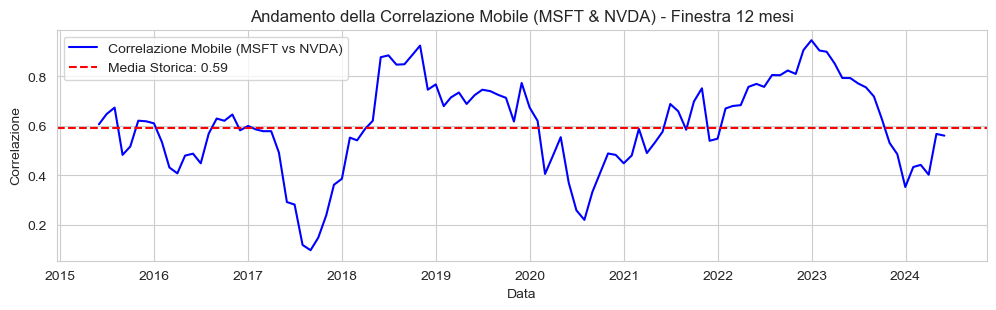

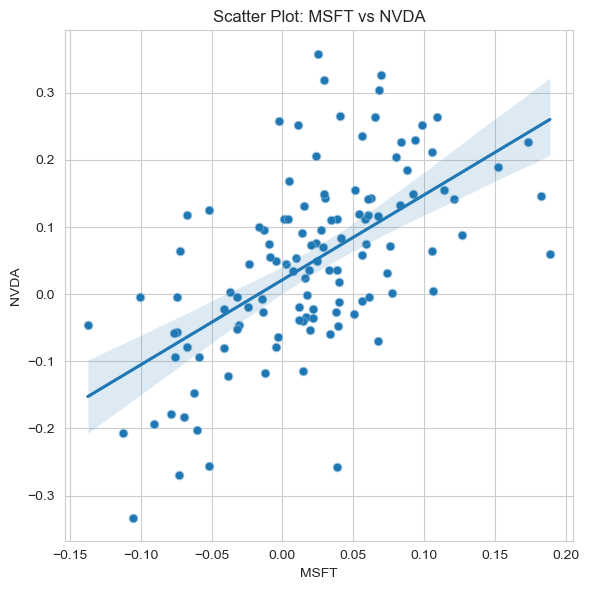

In [931]:
plot_correlazione_e_scatter(rlog_mensili, "MSFT", "NVDA", 12)

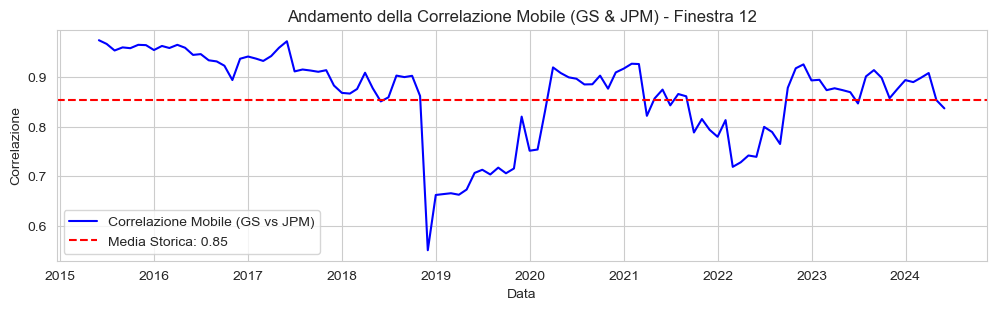

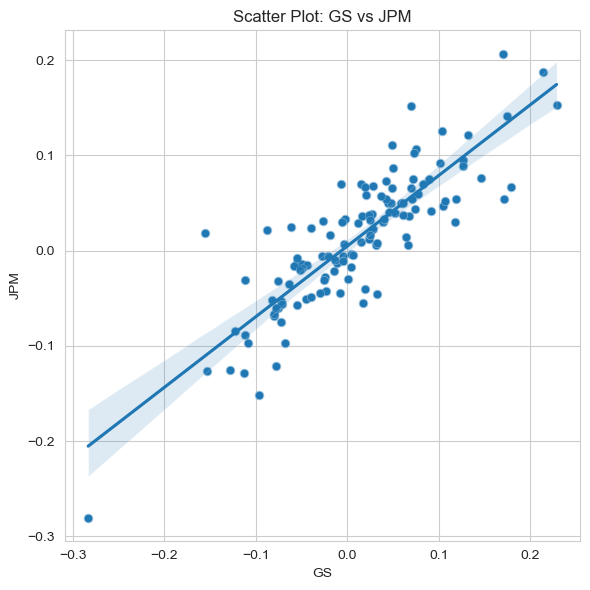

In [366]:
plot_correlazione_e_scatter(rlog_mensili, "GS", "JPM", 12)

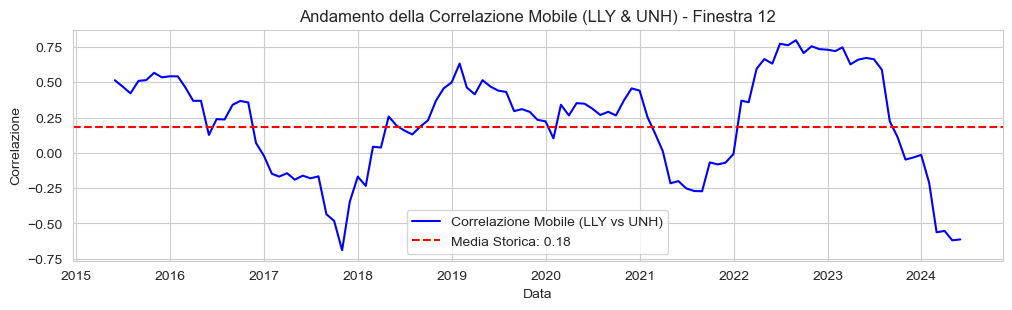

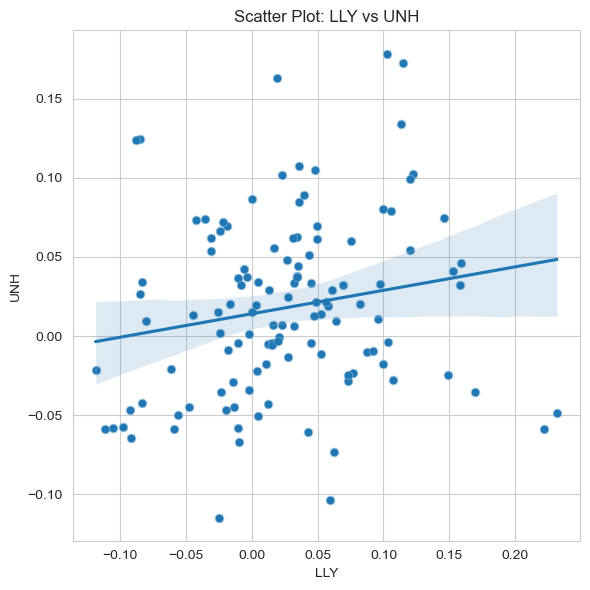

In [367]:
plot_correlazione_e_scatter(rs_mensili, "LLY", "UNH", 12)

# 3. Analisi di previsione

a. Costruire un modello di previsione ARIMA) per prevedere l’andamento di ciascun strumento finanziario, usando:

i. n (80) mesi come training set

ii. m (30) mesi come test set

iii. l (10) mesi per la previsione, che può essere svolto sia sull’intero periodo sia
ricorsivamente mese dopo mese

iv. Utilizzare gli ultimi (10) mesi per confrontare le previsioni con i valori effettivi

v. Verificare l’errore medio della previsione

In [370]:
n = 80  # mesi training
m = 30  # mesi test
l = 10  # mesi previsione

In [371]:
# periodo dei dati mensili
train_ARIMA = rlog_mensili.iloc[:n]
test_ARIMA = rlog_mensili.iloc[n:n+m] 
forecast_ARIMA = rlog_mensili.iloc[n+m:n+m+l]

In [372]:
'''# Previsione sull'intero periodo (circa 10 mesi)
full_forecast = model_fit.forecast(steps=l)
# errore assoluto della previsione
full_mae = mean_absolute_error(forecast_ARIMA['rlog_MSFT'], full_forecast)''';

In [945]:
def arima(df, stk):
    # Ricerca automatica dei parametri ARIMA
    model_auto = auto_arima(train_ARIMA[stk], seasonal=False, stepwise=True, suppress_warnings=True)
    # p → Numero di termini autoregressivi (AR) → Quanti valori passati usare? Indica quanti valori passati della serie influenzano il valore futuro.
    # d → Numero di differenziazioni (I) → Quante volte differenziare per ottenere una serie stazionaria? Indica quante volte dobbiamo differenziare la serie per renderla stazionaria.
    # q → Numero di termini di media mobile (MA) → Quanti errori passati usare? Indica quanti errori passati influenzano
    p, d, q = model_auto.order
    # print(p, d, m)
    
    history = list(train_ARIMA[stk].copy())
    
    # Validazione ricorsiva sul test set
    
    previsioni_test = []
    for i in range(len(test_ARIMA[stk])):
        # i.
        modello = ARIMA(history, order=(p, d, m)) # troppo costoso in termini di potenza [richiede troppo tempo per la visualizzazione del grafico]
        # modello = ARIMA(history, order=(1, 0, 1))
        modello_fit = modello.fit()
        prev = modello_fit.forecast()[0]
        previsioni_test.append(prev)
        # ii.
        history.append(test_ARIMA[stk].iloc[i])  # Aggiorna con il dato effettivo
    
    # Addestramento sul dataset completo (training + test)
    dataset_completo = rlog_mensili.iloc[:n+m]
    modello_finale = ARIMA(dataset_completo[stk], order=(p, d, m)) # troppo costoso in termini di potenza [richiede troppo tempo per la visualizzazione del grafico]
    # modello_finale = ARIMA(dataset_completo[stk], order=(1, 0, 1))
    modello_finale_fit = modello_finale.fit()

    # iii. Previsione dei prossimi 10 mesi
    previsioni = modello_finale_fit.forecast(steps=10)

    # iv. Utilizzare gli ultimi (10) mesi per confrontare le previsioni con i valori effettivi
    print("Valori Reali vs Previsioni:")
    for i in range(10):
            print(f"Mese {i+1}: Reale={forecast_ARIMA[stk].iloc[i]:.3f}, Previsto={previsioni[i]:.3f}")

    # v. Verificare l’errore medio della previsione (MAE)
    mae = mean_absolute_error(forecast_ARIMA[stk], previsioni)
    print(f'MAE sulla validazione: {mae:.3f}')
    
    # Visualizzazione grafica
    plt.figure(figsize=(12, 6))
    plt.plot(train_ARIMA[stk].index, train_ARIMA[stk], label='Training')
    plt.plot(test_ARIMA[stk].index, test_ARIMA[stk], label='Test')
    plt.plot(forecast_ARIMA[stk].index, forecast_ARIMA[stk], label='Valori Effettivi')
    plt.plot(forecast_ARIMA[stk].index, previsioni, label='Previsioni ARIMA', linestyle='--')
    plt.title(f'{stk}: Previsioni ARIMA vs Valori Effettivi')
    plt.xlabel('Data')
    plt.ylabel('Prezzo')
    plt.legend()
    plt.show();

# output:
# Il MAE (Mean Absolute Error o Errore Medio Assoluto) è una metrica comune per valutare l'accuratezza delle previsioni
# Intervallo teorico: da 0 a +∞
# Valore ottimale: 0 (previsioni perfette)

In [947]:
df_close.columns

Index(['GS', 'JPM', 'LLY', 'MSFT', 'NVDA', 'UNH'], dtype='object', name='Ticker')

Valori Reali vs Previsioni:
Mese 1: Reale=-0.073, Previsto=0.001
Mese 2: Reale=-0.014, Previsto=-0.023
Mese 3: Reale=-0.064, Previsto=0.030
Mese 4: Reale=0.131, Previsto=-0.002
Mese 5: Reale=0.126, Previsto=-0.059
Mese 6: Reale=-0.006, Previsto=0.043
Mese 7: Reale=0.019, Previsto=0.026
Mese 8: Reale=0.072, Previsto=-0.030
Mese 9: Reale=0.019, Previsto=0.043
Mese 10: Reale=0.060, Previsto=0.018
MAE sulla validazione: 0.072


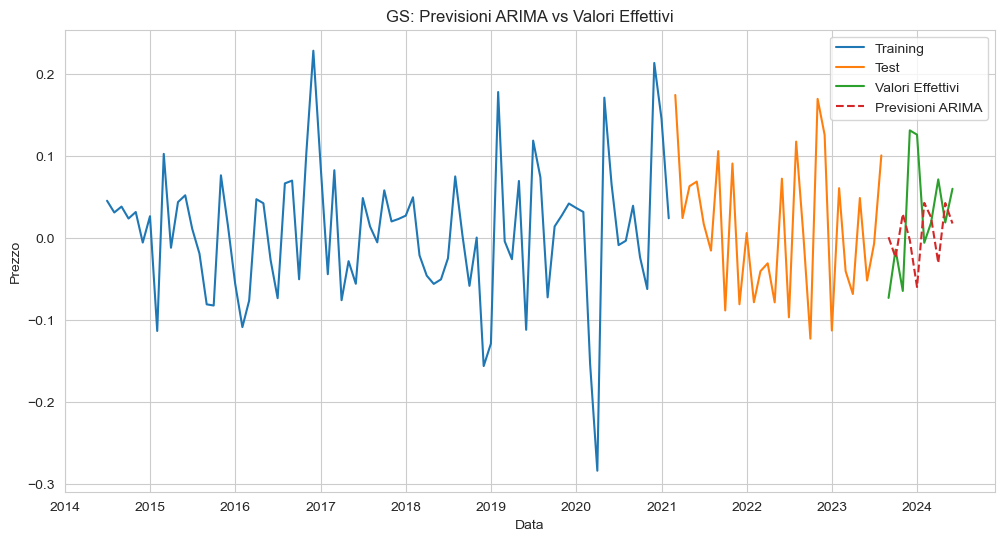

Valori Reali vs Previsioni:
Mese 1: Reale=-0.075, Previsto=0.048
Mese 2: Reale=-0.010, Previsto=0.009
Mese 3: Reale=-0.035, Previsto=0.033
Mese 4: Reale=0.122, Previsto=0.010
Mese 5: Reale=0.089, Previsto=-0.018
Mese 6: Reale=0.031, Previsto=-0.008
Mese 7: Reale=0.067, Previsto=0.040
Mese 8: Reale=0.075, Previsto=-0.023
Mese 9: Reale=-0.040, Previsto=0.048
Mese 10: Reale=0.037, Previsto=-0.023
MAE sulla validazione: 0.074


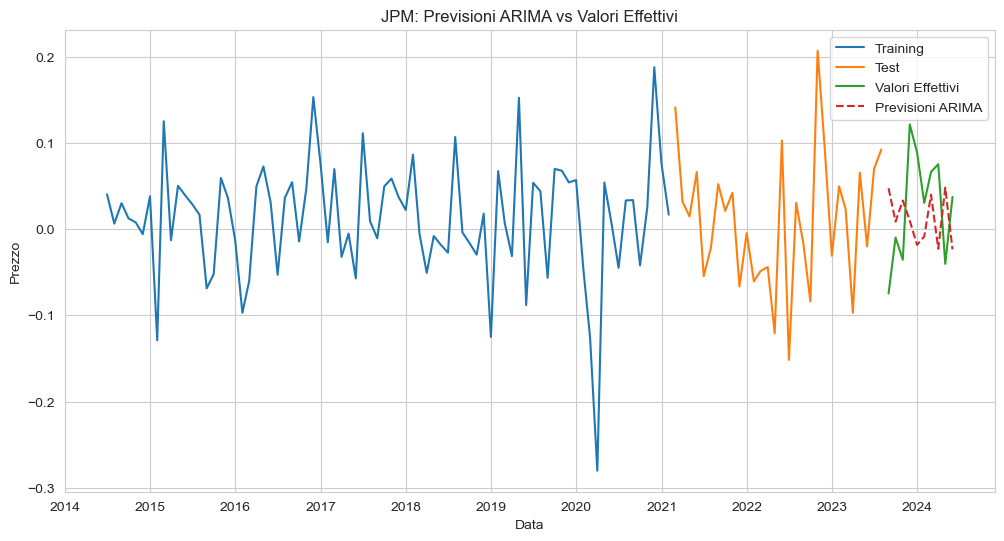

Valori Reali vs Previsioni:
Mese 1: Reale=0.210, Previsto=-0.017
Mese 2: Reale=-0.033, Previsto=0.079
Mese 3: Reale=0.027, Previsto=0.031
Mese 4: Reale=0.063, Previsto=0.027
Mese 5: Reale=-0.016, Previsto=0.026
Mese 6: Reale=0.106, Previsto=-0.004
Mese 7: Reale=0.164, Previsto=0.009
Mese 8: Reale=0.030, Previsto=0.001
Mese 9: Reale=0.000, Previsto=0.065
Mese 10: Reale=0.042, Previsto=-0.018
MAE sulla validazione: 0.084


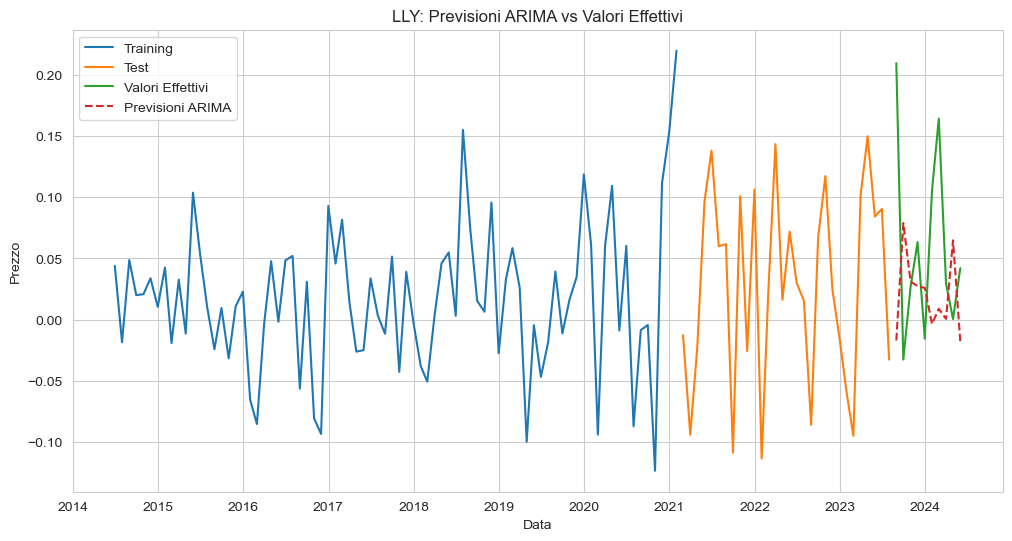

Valori Reali vs Previsioni:
Mese 1: Reale=-0.024, Previsto=-0.061
Mese 2: Reale=-0.038, Previsto=0.048
Mese 3: Reale=0.068, Previsto=0.009
Mese 4: Reale=0.121, Previsto=0.008
Mese 5: Reale=-0.008, Previsto=0.004
Mese 6: Reale=0.056, Previsto=0.026
Mese 7: Reale=0.041, Previsto=0.033
Mese 8: Reale=0.015, Previsto=-0.061
Mese 9: Reale=-0.077, Previsto=0.090
Mese 10: Reale=0.065, Previsto=0.054
MAE sulla validazione: 0.060


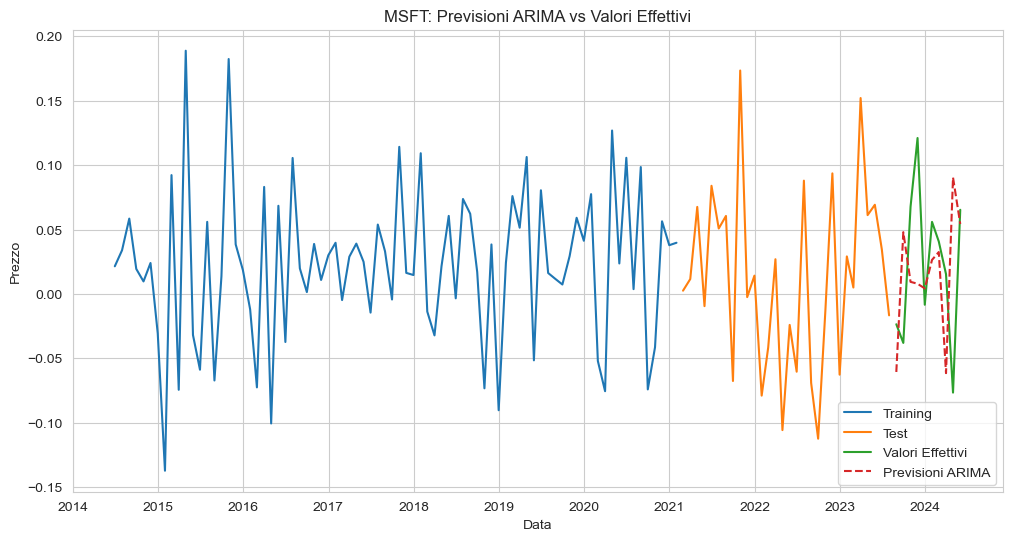

Valori Reali vs Previsioni:
Mese 1: Reale=0.045, Previsto=0.104
Mese 2: Reale=-0.121, Previsto=-0.014
Mese 3: Reale=-0.069, Previsto=0.038
Mese 4: Reale=0.142, Previsto=0.001
Mese 5: Reale=0.056, Previsto=-0.060
Mese 6: Reale=0.236, Previsto=0.029
Mese 7: Reale=0.265, Previsto=0.024
Mese 8: Reale=0.132, Previsto=0.183
Mese 9: Reale=-0.057, Previsto=0.042
Mese 10: Reale=0.265, Previsto=0.027
MAE sulla validazione: 0.137


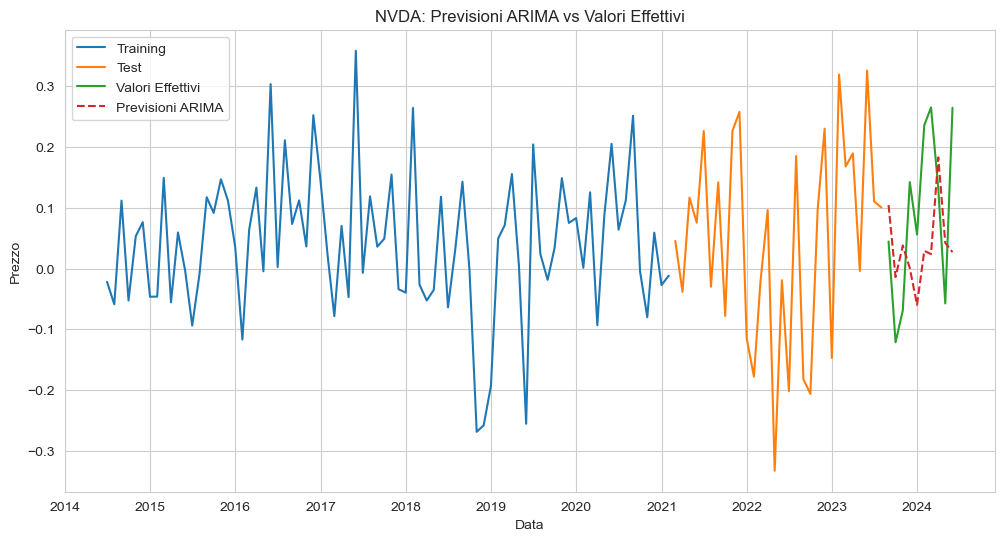

Valori Reali vs Previsioni:
Mese 1: Reale=-0.060, Previsto=-0.037
Mese 2: Reale=0.061, Previsto=0.006
Mese 3: Reale=0.061, Previsto=0.020
Mese 4: Reale=0.032, Previsto=0.047
Mese 5: Reale=-0.045, Previsto=-0.029
Mese 6: Reale=-0.031, Previsto=0.016
Mese 7: Reale=-0.037, Previsto=0.024
Mese 8: Reale=0.005, Previsto=0.008
Mese 9: Reale=-0.028, Previsto=0.045
Mese 10: Reale=-0.006, Previsto=-0.010
MAE sulla validazione: 0.034


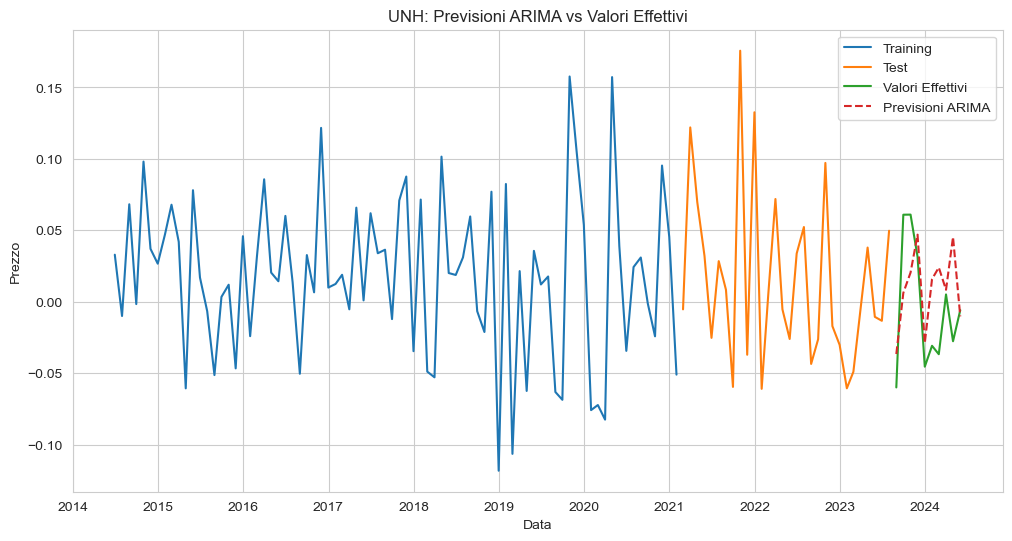

In [949]:
for stk in df_close.columns:
    arima(rlog_mensili, stk)

# 4. Stategie di trading e backtesting – Analisi tecnica

In [376]:
# a
def strategia_medie_mobili(df_close, stock, window1:int=20, window2:int=120):
    # copia del DataFrame della colonna Close
    # trasformazione della serie delle chiusure in un DataFrame
    df = pd.DataFrame(df_close[stock].copy())
    # creazione medie mobili: 20 e 120 [standard]
    df[f'{stock}_SMA{window1}'] = df[stock].rolling(window=window1, min_periods=1).mean()
    df[f'{stock}_SMA{window2}'] = df[stock].rolling(window=window2, min_periods=1).mean()

    # creazione strategia
    # prezzo di ieri (colonna close shiftata di un giorno)
    df['Price_yesterday'] = df[stock].shift(1)
    # calcolo il rapporto di variazione giornaliera
    df['Change'] = df[stock] / df['Price_yesterday']

    # Valuta la condizione data['SMA20'] > data['SMA120'] per ogni riga
    # - Se vero (SMA20 > SMA120): assegna 1
    # - Se falso (SMA20 ≤ SMA120): assegna 0
    df['invested_SMA'] = np.where(df[f'{stock}_SMA{window1}'] > df[f'{stock}_SMA{window2}'], 1, 0)

    # Rendimento dalla strategia
    # consigliato di lavorare su una copia
    # sma è il Dataframe che contiene solo la colonna 'invested_SMA' con valori 1
    sma = df[df['invested_SMA'] == 1].copy()
    # calcola il rendimento cumulato (composto per giorno)
    sma['Return'] = np.cumprod(sma['Change'])
    # calcola i rendimenti giornalieri
    sma['rtn'] = sma['Return'].pct_change()
    # calcola la volatilità annualizzata
    volatilità_annualizzata = sma['rtn'].std()*np.sqrt(252)
    # sharpe ratio annualizzato: è un numero che ti dice se un investimento vale il rischio che stai correndo.
    # sma['rtn'].mean()*252: rendimento medio annualizzato
    # Sharpe Ratio = 1: Buona performance
    # Sharpe Ratio > 1.5: Eccellente performance
    # Sharpe Ratio < 0: Strategia perdente
    sharpe_ratio_annualizzato = sma['rtn'].mean()*252 / volatilità_annualizzata

    return sma

    # print(df)
    # sma: df con solo valori invested_SMA == 1
    print(sma)
    print(f"volatilità annualizzata: {volatilità_annualizzata}" )
    print(f'sharpe ratio annulizzato: {sharpe_ratio_annualizzato}')

In [380]:
'''strategia_medie_mobili(df_close, 'GS', 20, 120)'''

,GS,GS_SMA20,GS_SMA120,Price_yesterday,Change,invested_SMA,Return,rtn
Date,,,,,,,,
2014-06-30,135.894333,135.341604,135.081544,135.358658,1.003957,1,1.003957,NaN
2014-07-01,135.382980,135.544908,135.095245,135.894333,0.996237,1,1.000180,-0.003763
2014-07-02,135.447876,135.727518,135.110577,135.382980,1.000479,1,1.000659,0.000479
2014-07-03,137.533722,136.006707,135.211541,135.447876,1.015400,1,1.016069,0.015400
2014-07-07,136.170242,136.071229,135.249890,137.533722,0.990086,1,1.005996,-0.009914
...,...,...,...,...,...,...,...,...
2024-05-23,448.261353,439.883191,388.141425,452.400055,0.990852,1,2.734340,-0.009148
2024-05-24,451.225983,441.527420,389.080719,448.261353,1.006614,1,2.752424,0.006614
2024-05-28,449.885498,442.946121,390.001070,451.225983,0.997029,1,2.744247,-0.002971


In [381]:
# b
def buy_and_hold(df_close, stock):
    df = pd.DataFrame(df_close[stock].copy())
    # Rendimento del buy and hold
    df['Change'] = df / df.shift(1)
    df['Buy_and_hold'] = np.cumprod(df['Change'])
    # calcola le variazione percentuali dei rendimenti 
    df['rtn'] = df['Buy_and_hold'].pct_change()
    volatilità = df['rtn'].std()

    return df
    print(df)

In [382]:
'''buy_and_hold(df_close, 'GS')'''

,GS,Change,Buy_and_hold,rtn
Date,,,,
2014-06-02,129.880341,NaN,NaN,NaN
2014-06-03,131.316895,1.011061,1.011061,NaN
2014-06-04,131.795670,1.003646,1.014747,0.003646
2014-06-05,131.949951,1.001171,1.015935,0.001171
2014-06-06,134.879807,1.022204,1.038493,0.022204
...,...,...,...,...
2024-05-23,448.261353,0.990852,3.451341,-0.009148
2024-05-24,451.225983,1.006614,3.474167,0.006614
2024-05-28,449.885498,0.997029,3.463846,-0.002971


In [383]:
'''print(strategia_medie_mobili(df_close, 'NVDA', 20, 120)['Return'])'''

"print(strategia_medie_mobili(df_close, 'NVDA', 20, 120)['Return'])"

In [384]:
# b
def grafico_strategia_vs_buy_and_hold(df, stock, media_mobile_1=20, media_mobile_2=120):

    df_close = pd.DataFrame(df['Close'][stock].copy())
    strategia = strategia_medie_mobili(df_close, stock, media_mobile_1, media_mobile_2)
    bh = buy_and_hold(df_close, stock)
    
    # print(strategia['Return'])
    plt.figure(figsize=(12,5))
    plt.title(f'{stock}_strategia_vs_buy_and_hold')
    plt.plot(bh['Buy_and_hold'], label = 'Buy and hold')
    plt.plot(strategia['Return'], label = 'SMA')
    plt.legend()
    # salva_grafico(f'{stock} Strategia_vs_Buy_and_Hold', 'Desktop/Grafici BISF/grafico_strategia_vs_buy_and_hold')   
    plt.show()

    # c.
    # volume dello stock
    volume = df['Volume'][stock]
    plt.figure(figsize=(12,2))
    plt.title(f'{stock}_Volume')
    plt.bar(x=volume.index, height=volume, width=0.8, label = 'Volume', linewidth=0.5, color='r')
    plt.legend()
    # salva_grafico(f'{stock} Volume', 'Desktop/Grafici BISF/grafico_strategia_vs_buy_and_hold')
    plt.show()

    # grafico giusto
    # sma ha dei movimenti di linee orizzontali perchè sono i valori '0' mancanti della colonna invested_SMA

In [385]:
'''df_close'''

Ticker,GS,JPM,LLY,MSFT,NVDA,UNH
Date,,,,,,
2014-06-02,129.880341,40.953003,48.341057,34.521286,0.450631,67.109680
2014-06-03,131.316895,41.137978,48.227299,34.098122,0.448728,67.455956
2014-06-04,131.795670,41.197170,48.121647,34.123528,0.449204,67.987923
2014-06-05,131.949951,41.900066,48.414188,34.876743,0.451107,67.388390
2014-06-06,134.879807,42.151619,48.454830,35.105247,0.452773,67.498138
...,...,...,...,...,...,...
2024-05-23,448.261353,192.456543,804.600403,424.529083,103.764908,508.694855
2024-05-24,451.225983,196.160660,803.585205,427.670776,106.434029,500.171143
2024-05-28,449.885498,194.978073,804.013184,427.829865,113.863586,495.751801


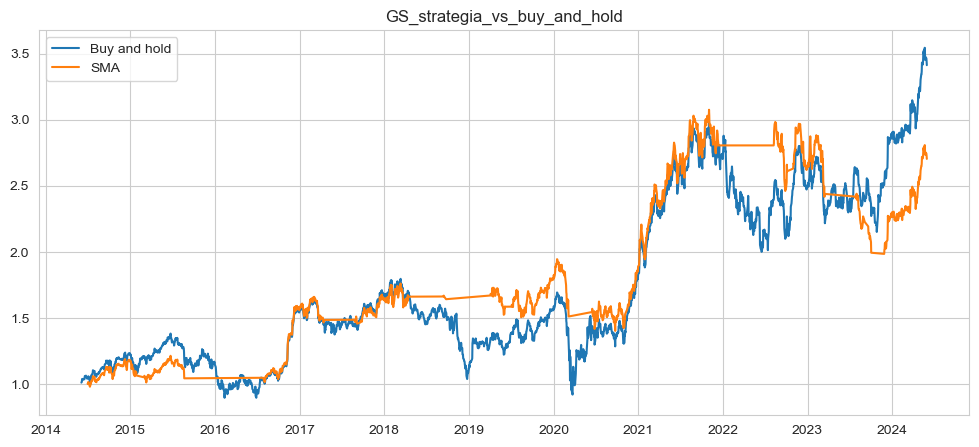

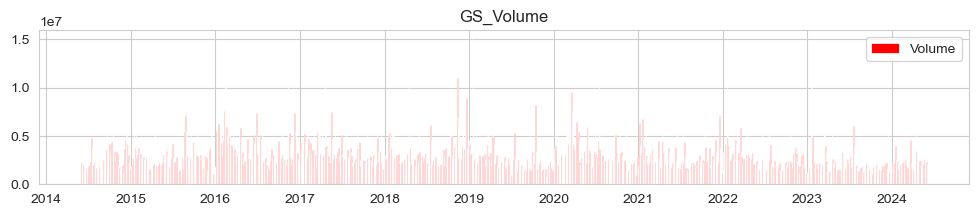

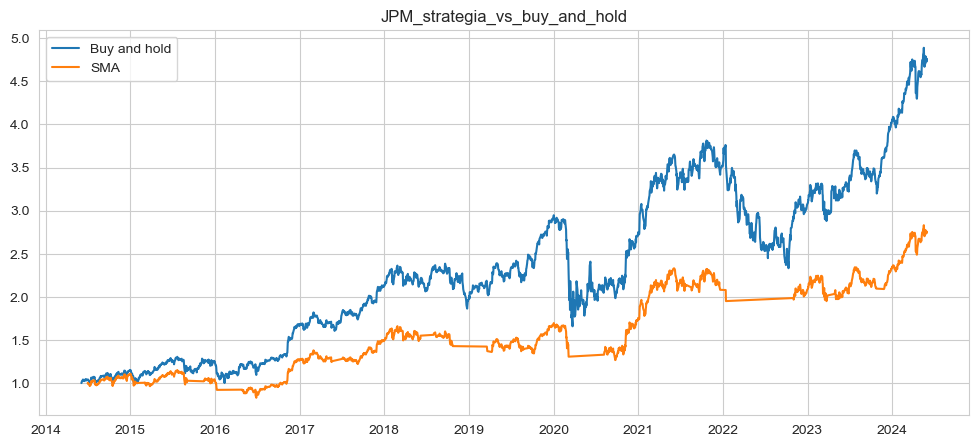

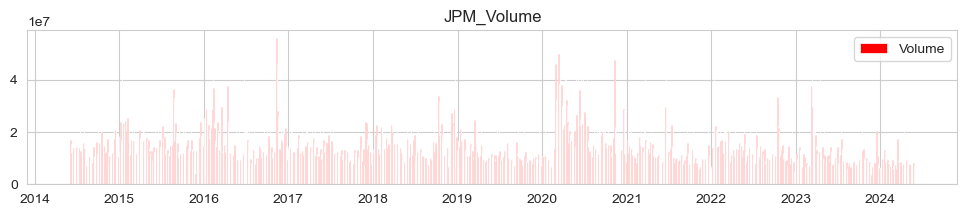

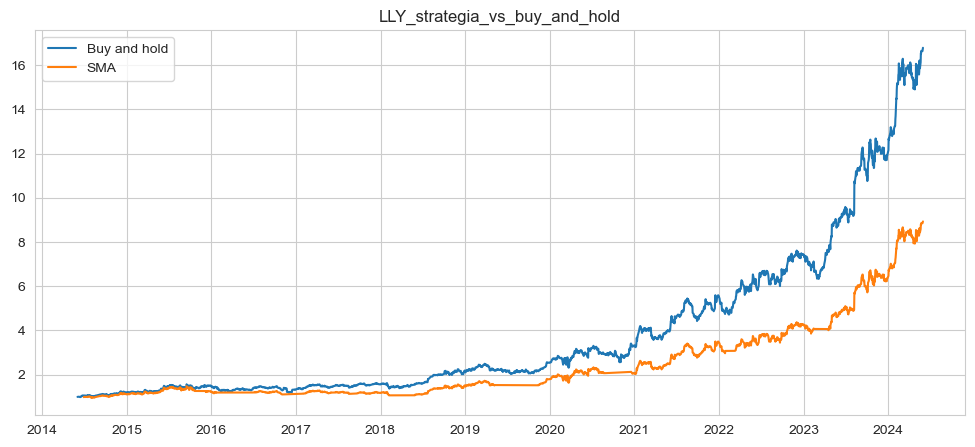

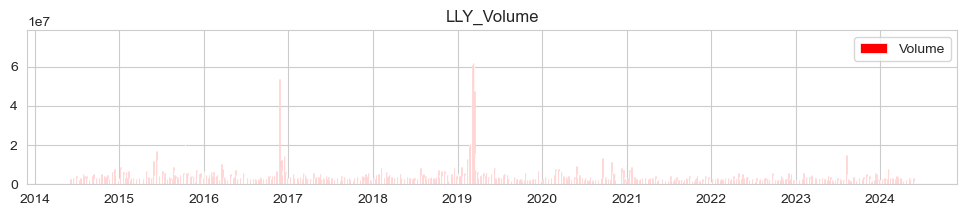

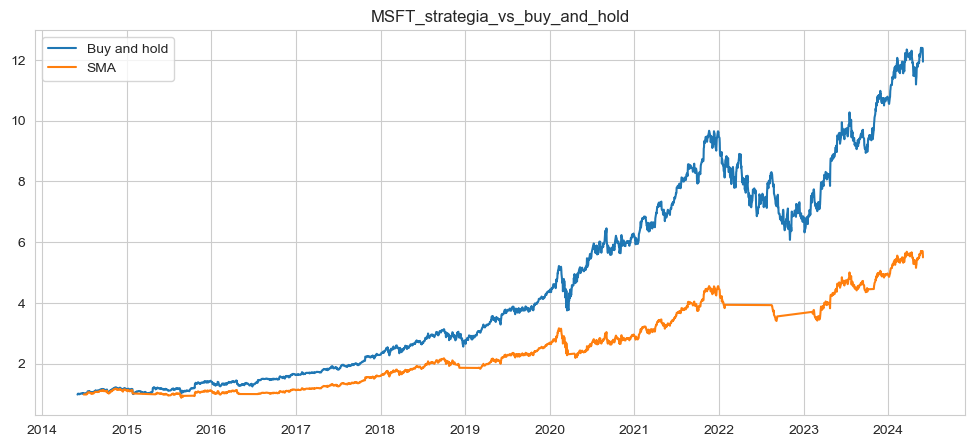

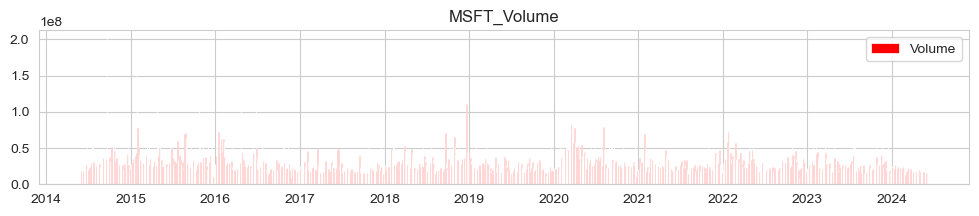

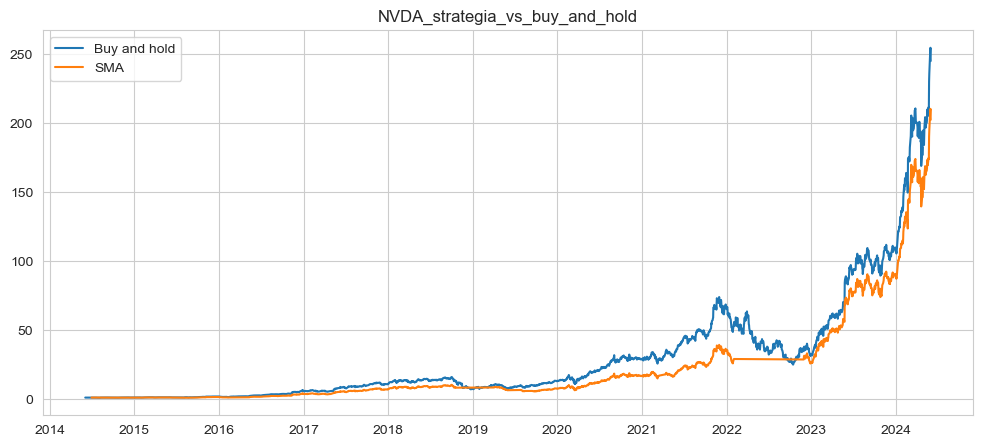

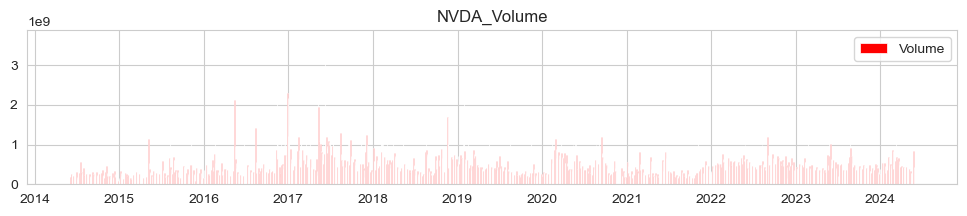

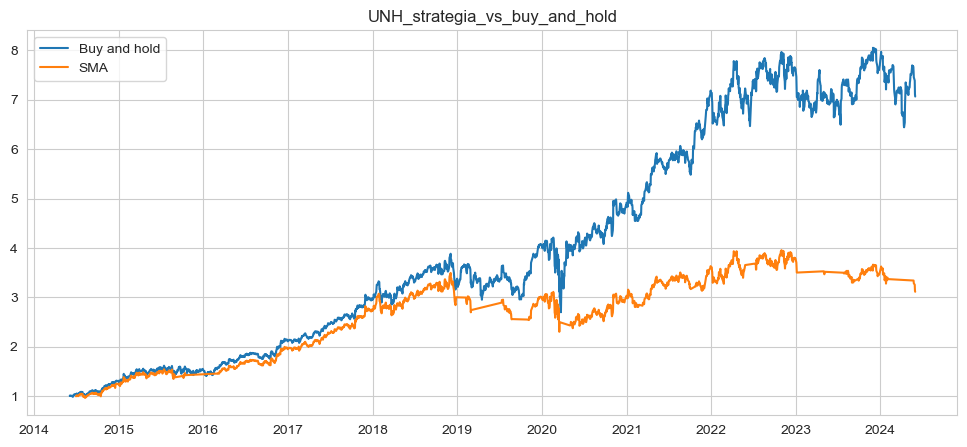

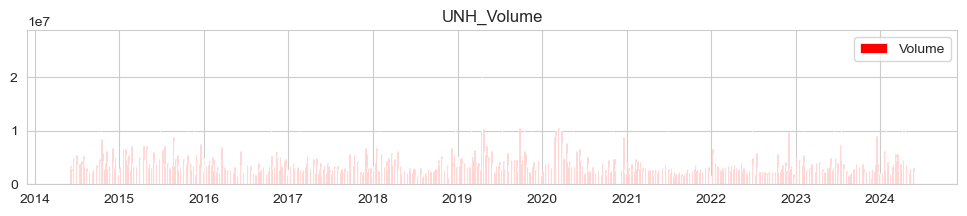

In [933]:
for stk in df_close.columns:
    grafico_strategia_vs_buy_and_hold(df, stk)

# 5. CAPM: Capital Asset Pricing Model

descrive la relazione tra rischio e rendimento atteso di un investimento.

In [108]:
# a.
market_benchmark = '^GSPC'
indice = yf.download(tickers=market_benchmark, start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [112]:
indice

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2014-06-02,1924.969971,1925.880005,1915.979980,1923.869995,2509020000
2014-06-03,1924.239990,1925.069946,1918.790039,1923.069946,2867180000
2014-06-04,1927.880005,1928.630005,1918.599976,1923.060059,2793920000
2014-06-05,1940.459961,1941.739990,1922.930054,1928.520020,3113270000
2014-06-06,1949.439941,1949.439941,1942.410034,1942.410034,2864300000
...,...,...,...,...,...
2024-05-23,5267.839844,5341.879883,5256.930176,5340.259766,3869520000
2024-05-24,5304.720215,5311.649902,5278.390137,5281.450195,3005510000


In [392]:
'''rendimenti_mensili = indice['Close'].resample('M').last().pct_change().dropna()'''

"rendimenti_mensili = indice['Close'].resample('M').last().pct_change().dropna()"

In [114]:
def beta(indice, df, stock):
    rendimenti_mensili_indice = indice['Close'].resample('M').last().pct_change().dropna()
    rendimenti_mensili_stock = df['Close'][stock].resample('M').last().pct_change().dropna()
    X = pd.concat([rendimenti_mensili_indice, rendimenti_mensili_stock], axis=1)
    # calcola la covarianza solo tra le due colonne
    covariance = X.cov().iloc[0,1]
    # benchmark = variabile di riferimento
    benchmark_variance = X['^GSPC'].var()
    # calcolo del beta B = covarianza(Ri, Rm)/varianza(Rm) Ri = rendimento del titolo; Rm = rendimento del mercato
    # misura la sensibilità di un titolo (o di un portafoglio) rispetto ai movimenti di mercato
    beta = covariance / benchmark_variance
    # print(f'il beta di {stock} è: {beta}')
    return beta

    # print(covariance)
    # print(benchmark_variance)
    # print(beta)

'''
# beta = 1: titolo si muove in linea con il mercato, se il mercato aumenta allora aumenta anche il titolo
# beta > 1: titolo è più volatile del mercato, quindi il titolo aumenta più velocemente del mercato (in percentuale)
# beta < 1: titolo meno volatile del mercato, quindi il titolo aumenta più lentamente del mercato (in percentuale) 
''';


In [116]:
# TODO: calcolare il beta per ogni stock
for stk in df_close.columns:
    beta(indice, df, stk)

In [118]:
# b.

# inseriamo il risk free
# '^IRX': Indice che traccia il rendimento dei Treasure Bill (Buoni del tesoro) emessi dal governo degli Stati Uniti
risk_free = '^IRX'

In [120]:
rs_mensili.mean() * 12 * 100

GS      16.192249
JPM     18.583962
LLY     31.274942
MSFT    27.310649
NVDA    66.910473
UNH     21.539545
dtype: float64

In [397]:
def CAPM(risky_asset, market_benchmark, risk_free, beta):
    # scarichiamo i dati
    df = yf.download([risky_asset, market_benchmark, risk_free], start=start_date, end=end_date)
    # aggiunto tasso di rendimento primo di rischio espresso come tasso annuo
    X1 = df['Close'].rename(columns={risky_asset:'asset', market_benchmark:'market', risk_free: 'risk_free'}).resample('ME').last()
    # beta
    beta = beta(indice, df, risky_asset)
    # prendo l'ultimo tasso di rendimento privo di rischio annuo 
    risk_free_rate = X1['risk_free'].iloc[-1]
    # calcolo media giornaliera
    media_giornaliera_market = np.mean(X1['market'].pct_change())
    # anuualizzazione del rendimento (252 giorni lavorativi)
    market_return = (1 + media_giornaliera_market)**252 - 1
    # market_return = (X1['market'].pct_change().iloc[-1])

    # rendimento medio composto annuale
    cagr = ((X1['asset'][-1] / X1['asset'][0])**(1/10) - 1 ) * 100
    
    # formula CAPM
    expected_return = risk_free_rate + beta * (market_return - risk_free_rate)

    # print(df)
    print(' ')
    print(f'{risky_asset}:')
    print(f'il beta è: {beta:.3f}')
    print(f'risk_free_rate: {risk_free_rate:.3f}%')
    print(f'market_return: {market_return:.3f}%')
    print(f'CAPM/expected_return: {expected_return:.3f}%')
    print(f'rendimento medio annuale: {cagr:.3f}%')
    print(f'outperformance: {cagr - expected_return:.3f}%')
    print(' ')
    return expected_return

In [398]:
for stk in df_close.columns:
    CAPM(stk, market_benchmark, risk_free, beta)

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


 
GS:
il beta è: 1.361
risk_free_rate: 5.248%
market_return: 9.211%
CAPM/expected_return: 10.640%
rendimento medio annuale: 12.548%
outperformance: 1.908%
 
 
JPM:
il beta è: 1.138
risk_free_rate: 5.248%
market_return: 9.211%
CAPM/expected_return: 9.758%
rendimento medio annuale: 16.409%
outperformance: 6.651%
 
 
LLY:
il beta è: 0.352
risk_free_rate: 5.248%
market_return: 9.211%
CAPM/expected_return: 6.641%
rendimento medio annuale: 31.998%
outperformance: 25.357%
 


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed

 
MSFT:
il beta è: 0.990
risk_free_rate: 5.248%
market_return: 9.211%
CAPM/expected_return: 9.170%
rendimento medio annuale: 27.865%
outperformance: 18.695%
 
 
NVDA:
il beta è: 1.806
risk_free_rate: 5.248%
market_return: 9.211%
CAPM/expected_return: 12.404%
rendimento medio annuale: 73.727%
outperformance: 61.323%
 
 
UNH:
il beta è: 0.595
risk_free_rate: 5.248%
market_return: 9.211%
CAPM/expected_return: 7.608%
rendimento medio annuale: 21.192%
outperformance: 13.584%
 


In [122]:
# c. Calcolare l’esposizione di ciascun titolo o ETF ai fattori di rischio Fama-French
df_three_factor = web.DataReader('F-F_Research_Data_Factors', 'famafrench', start = start_date, end = end_date)[0][1:]
df_three_factor = df_three_factor/100

In [400]:
df_three_factor

,Mkt-RF,SMB,HML,RF
Date,,,,
2014-06,0.0261,0.0309,-0.0070,0.0000
2014-07,-0.0204,-0.0430,0.0004,0.0000
2014-08,0.0424,0.0040,-0.0045,0.0000
2014-09,-0.0197,-0.0370,-0.0135,0.0000
2014-10,0.0252,0.0420,-0.0180,0.0000
...,...,...,...,...
2024-01,0.0070,-0.0502,-0.0247,0.0047
2024-02,0.0507,-0.0022,-0.0352,0.0042
2024-03,0.0283,-0.0251,0.0422,0.0043


In [124]:
rc = pd.DataFrame()
rc_mtl = df_close.pct_change().resample('ME').agg(lambda x: (x+1).prod() - 1)
# per avere lo stesso identico indice -> per la merge
rc_mtl.index = df_three_factor.index

In [126]:
rc_mtl

Ticker,GS,JPM,LLY,MSFT,NVDA,UNH
Date,,,,,,
2014-06,0.046304,0.041012,0.045049,0.022310,-0.021119,0.033525
2014-07,0.032429,0.007865,-0.017854,0.035012,-0.056095,-0.008563
2014-08,0.039310,0.030865,0.049321,0.059169,0.116345,0.069463
2014-09,0.024901,0.013288,0.020296,0.020471,-0.051414,-0.000730
2014-10,0.034973,0.010748,0.022822,0.012727,0.059079,0.101565
...,...,...,...,...,...,...
2024-01,-0.004562,0.031365,0.107545,0.057281,0.242418,-0.027979
2024-02,0.020304,0.067102,0.169438,0.042318,0.285809,-0.035448
2024-03,0.073615,0.076535,0.032215,0.017116,0.142181,0.006179


In [128]:
merge = pd.merge(rc_mtl, df_three_factor, on='Date')

In [130]:
merge

,GS,JPM,LLY,MSFT,NVDA,UNH,Mkt-RF,SMB,HML,RF
Date,,,,,,,,,,
2014-06,0.046304,0.041012,0.045049,0.022310,-0.021119,0.033525,0.0261,0.0309,-0.0070,0.0000
2014-07,0.032429,0.007865,-0.017854,0.035012,-0.056095,-0.008563,-0.0204,-0.0430,0.0004,0.0000
2014-08,0.039310,0.030865,0.049321,0.059169,0.116345,0.069463,0.0424,0.0040,-0.0045,0.0000
2014-09,0.024901,0.013288,0.020296,0.020471,-0.051414,-0.000730,-0.0197,-0.0370,-0.0135,0.0000
2014-10,0.034973,0.010748,0.022822,0.012727,0.059079,0.101565,0.0252,0.0420,-0.0180,0.0000
...,...,...,...,...,...,...,...,...,...,...
2024-01,-0.004562,0.031365,0.107545,0.057281,0.242418,-0.027979,0.0070,-0.0502,-0.0247,0.0047
2024-02,0.020304,0.067102,0.169438,0.042318,0.285809,-0.035448,0.0507,-0.0022,-0.0352,0.0042
2024-03,0.073615,0.076535,0.032215,0.017116,0.142181,0.006179,0.0283,-0.0251,0.0422,0.0043


In [238]:
# funzione fama_french
def fama_french(df, stock):
    df[f'excess_rtn_{stock}'] = df[stock] - df.RF
    y = df[f'excess_rtn_{stock}']
    X = df[['Mkt-RF', 'SMB', 'HML']]
    X_sm = sm.add_constant(X)
    model = sm.OLS(y, X_sm)
    results = model.fit()
    # print(f"\nRisultati modello Fama-French per: {stock}\n")
    # print(results.summary())

    return results

In [240]:
for stk in df_close.columns:
    fama_french(merge, stk)

'''
R-squared: quanta % della variabilità dei rendimenti dell'azione è spiegato dai 3 fattori Fama-French
coef (Coefficiente): peso/effetto della variabile sul risultato. Se il mercato sale dell'1%, l'azione tende a salire di tot% (a parità di altri fattori).
std err (Errore Standard): L'incertezza nella stima del coefficiente. Più è piccolo, più la stima è precisa.
t (Statistica t): Quanto è "grande" il coefficiente rispetto al suo errore. |t| > 2 → coefficiente significativo.
P>|t| (p-value): p < 0.05 → Significativo (95% di certezza che l'effetto esista).

const
Mkt-RF: è il beta -> è la percentuale in cui cresce con il mercato: se il beta è 1.5 e il mercato sale o scende del 1% allora sale\scende di 1.5 volte
SMB (Small Minus Big): Differenza tra azione piccole e grandi: Quanto le piccole aziende (small-cap) rendono in più rispetto alle grandi (large-cap)
Se un titolo ha beta SMB positivo, significa che si comporta più come una small-cap.

HML (High Minus Low): Differenza tra azioni 'value' e 'growth':  Quanto le azioni value (sottovalutate, come quelle di banche o utility) rendono più delle growth (crescita, come tech).
Se un titolo ha beta HML POSITIVO → È VALUE!
Sono considerate più rischiose, Offrono rendimenti più alti per compensare il rischio.

Se un titolo ha beta HML NEGATIVO → È GROWTH!
Meno rischiose nel breve (alta domanda), ma più volatili.
Rendono meno delle value in media, ma possono esplodere.
''';

In [250]:
for stk in df_close.columns:
    model = fama_french(merge, stk)
    print(model.summary())

                            OLS Regression Results                            
Dep. Variable:          excess_rtn_GS   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     84.55
Date:                Tue, 06 May 2025   Prob (F-statistic):           4.60e-29
Time:                        18:30:17   Log-Likelihood:                 201.40
No. Observations:                 120   AIC:                            -394.8
Df Residuals:                     116   BIC:                            -383.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015      0.004      0.357      0.7

In [248]:
import pandas as pd
import statsmodels.api as sm

# ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––
# 1) Assicurati di avere già:
#    - merge: DataFrame che contiene i rendimenti mensili dei titoli (colonne = tickers)
#      + le colonne ['Mkt-RF','SMB','HML','RF'], indicizzate per data.
# ––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––––

# 2) Prepara un DataFrame vuoto per raccogliere i parametri
cols_ff = ['const','Mkt-RF','SMB','HML']
ff_params = pd.DataFrame(index=tickers, columns=cols_ff, dtype=float)

# 3) Loop sui titoli, stima e salva i parametri
for stk in stk_tickers:
    # salva i coefficienti nella tabella
    ff_params.loc[stk] = (fama_french(merge, stk)).params[cols_ff]

# 4) Controlla la tabella finale
print(ff_params)


           const    Mkt-RF       SMB       HML
Ticker                                        
GS      0.001540  1.295370  0.159777  0.708615
JPM     0.005696  1.085046  0.063791  0.849139
LLY     0.021046  0.319046  0.062436 -0.449867
MSFT    0.009816  1.052367 -0.684895 -0.397958
NVDA    0.035472  1.788323 -0.132547 -0.924649
UNH     0.011129  0.585634 -0.101471  0.042013


# 6 Strategie di trading e backtesting - Strategie Dinamiche

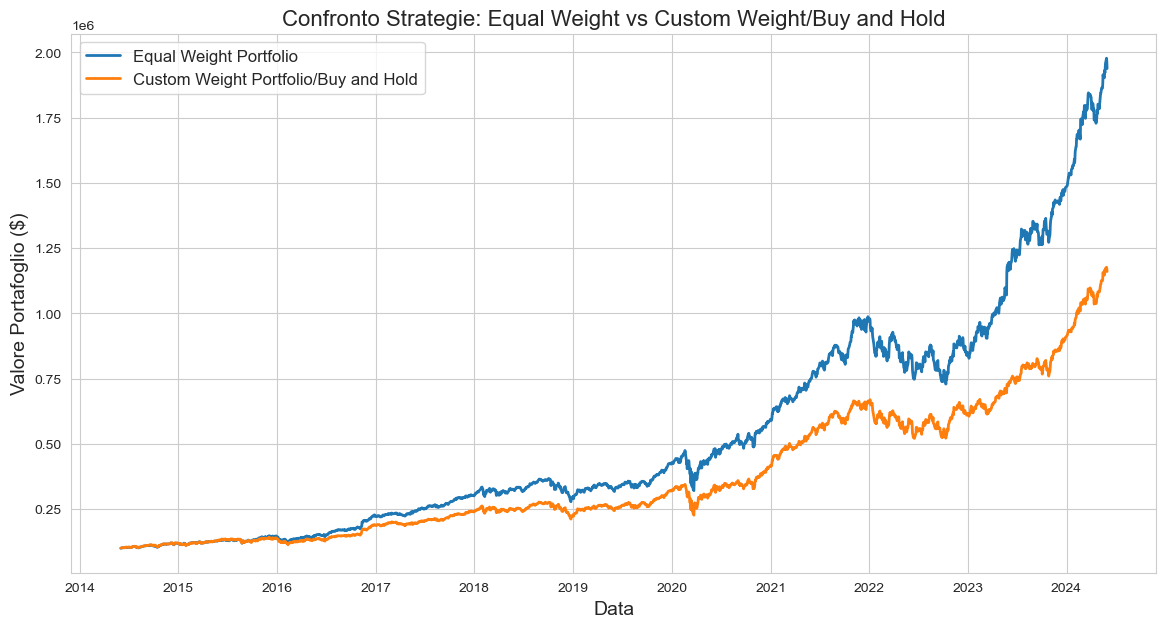


Statistiche di Performance:
                            Total Return (%)  Annualized Return  \
Strategy                                                          
Equal Weight                       1838.2021             0.3455   
Custom Weight/Buy and Hold         1057.4514             0.2780   

                            Annualized Volatility  Sharpe Ratio  Max Drawdown  
Strategy                                                                       
Equal Weight                               0.2221        1.5559        0.1304  
Custom Weight/Buy and Hold                 0.2146        1.2953        0.1260  


In [192]:
# Configurazione
'''stk_tickers = ['MSFT', 'NVDA', 'LLY', 'JPM', 'UNH', 'GS']
start_date = '2014-05-31'
end_date = '2024-05-31''' # dati iniziali

initial_capital = 100000  # Capitale iniziale

# Simula un portafoglio con pesi personalizzati
def simulate_custom_weight(data, weights, initial_capital):
    returns = data.pct_change()
    portfolio_returns = returns.dot(weights)
    portfolio_value = initial_capital * (1 + portfolio_returns).cumprod()
    return portfolio_value

# Statistiche performance
def calculate_stats(portfolio_values, name):
    portfolio_values.dropna(inplace=True)
    returns = portfolio_values.pct_change()
    total_return = (portfolio_values[-1] / portfolio_values[0] - 1) * 100
    annualized_return = (portfolio_values[-1] / portfolio_values[0]) ** (252/len(portfolio_values)) - 1
    volatility = returns.std() * np.sqrt(252)
    sharpe_ratio = annualized_return / volatility
    max_drawdown = (portfolio_values.cummax() - portfolio_values).max() / portfolio_values.cummax().max()
    
    stats = {
        'Strategy': name,
        'Total Return (%)': total_return,
        'Annualized Return': annualized_return,
        'Annualized Volatility': volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Max Drawdown': max_drawdown
    }
    return stats

def simulate_equal_weight_with_rebalancing(data, initial_capital, rebalance_freq=90):
    n_assets = len(data.columns)
    equal_weights = np.array([1/n_assets] * n_assets)
    portfolio_value = pd.Series(index=data.index, dtype=float)
    weights_history = pd.DataFrame(index=data.index, columns=data.columns)
    
    # Inizializzazione
    portfolio_value.iloc[0] = initial_capital
    weights_history.iloc[0] = equal_weights
    current_weights = equal_weights.copy()
    
    for i in range(1, len(data)):
        days_since_last_rebalance = (data.index[i] - data.index[i-1]).days
        
        # Verifica se è il momento di ribilanciare
        if (data.index[i] - data.index[0]).days % rebalance_freq == 0:
            current_weights = equal_weights.copy()
        
        # Calcola il rendimento giornaliero
        daily_returns = data.iloc[i] / data.iloc[i-1] - 1
        portfolio_return = np.dot(current_weights, daily_returns)
        
        # Aggiorna il valore del portafoglio
        portfolio_value.iloc[i] = portfolio_value.iloc[i-1] * (1 + portfolio_return)
        
        # Aggiorna i pesi dopo il movimento dei prezzi
        
        current_weights = current_weights * (1 + daily_returns)
        current_weights = current_weights / current_weights.sum()  # Normalizza
        
        # Registra i pesi
        current_weights = current_weights.astype(float)
        weights_history.iloc[i] = current_weights
    
    return portfolio_value, weights_history
# Esegui la simulazione
equal_weight_portfolio, weights = simulate_equal_weight_with_rebalancing(df_close, initial_capital, rebalance_freq=90)
# equal_weight_portfolio, weights = simulate_equal_weight_with_rebalancing(df_close, initial_capital, rebalance_freq=21)
# equal_weight_portfolio = simulate_equal_weight_with_rebalancing(df_close, initial_capital, rebalance_freq=21)

# Portafoglio con pesi personalizzati (esempio: pesi basati sulla capitalizzazione)
custom_weights = np.array([0.3, 0.2, 0.2, 0.1, 0.1, 0.1])  # Esempio di pesi non uniformi
custom_weight_portfolio = simulate_custom_weight(df_close, custom_weights, initial_capital)

# Visualizza i risultati
plt.figure(figsize=(14, 7))
plt.plot(equal_weight_portfolio, label='Equal Weight Portfolio', linewidth=2)
plt.plot(custom_weight_portfolio, label='Custom Weight Portfolio/Buy and Hold', linewidth=2)
plt.title('Confronto Strategie: Equal Weight vs Custom Weight/Buy and Hold', fontsize=16)
plt.xlabel('Data', fontsize=14)
plt.ylabel('Valore Portafoglio ($)', fontsize=14)
plt.legend(fontsize=12)
# salva_grafico('Confronto Strategie: Equal Weight vs Custom Weight-Buy and Hold')
plt.show();

# Calcola e mostra le statistiche
stats_equal = calculate_stats(equal_weight_portfolio, 'Equal Weight')
stats_custom = calculate_stats(custom_weight_portfolio, 'Custom Weight/Buy and Hold')
# print(equal_weight_portfolio)

stats_df = pd.DataFrame([stats_equal, stats_custom])
stats_df.set_index('Strategy', inplace=True)

print("\nStatistiche di Performance:")
print(stats_df.round(4))

# 7. Costruzione di portafoglio

In [258]:
# a. Costruire il portafoglio ottimale in termini di media-varianza utilizzando i primi 108 mesi di dati, 
# sia con metodo analitico sia con metodo di simulazione, utilizzando sia i rendimenti passati 
# sia i rendimenti attesi costruiti nella parte 6

period = 108 # 108 mesi = 9 anni
equal_weight_portfolio.dropna(inplace=True)
avg_equal_weight_portfolio = equal_weight_portfolio[0:period].mean()

## metodo di simulazione

In [261]:
n_port = 10 ** 5 # 10 mila portafogli di analizzare
periodo = 108 # mesi
n_assets = len(stk_tickers)
# expected_returns
avg_returns = rs_mensili[:periodo].mean() * 12 # * 12 per farlo diventare annuale
cov_mat = rs_mensili[:periodo].cov() * 12

In [263]:
# Simuliamo portafogli con pesi causali
np.random.seed(88)
rand_weights = np.random.random(size=(n_port, n_assets)) # pesi casuali generati
rand_weights /= np.sum(rand_weights, axis=1)[:, np.newaxis] # assicura che la somma dei pesi (totale) per ciascun portafoglio sia uguale a 1: ogni portafogio deve avere peso 1

In [264]:
portf_rtns = np.dot(rand_weights, avg_returns)
portf_vol = []
for i in range(0, len(rand_weights)):
    portf_vol.append(np.sqrt(np.dot(rand_weights[i].T, 
                                    np.dot(cov_mat, rand_weights[i]))))
portf_vol = np.array(portf_vol)  
portf_sharpe_ratio = portf_rtns / portf_vol

In [265]:
# Creiamo un df con tutti i dati
portf_results_df = pd.DataFrame({'returns': portf_rtns,
                                 'volatility': portf_vol,
                                 'sharpe_ratio': portf_sharpe_ratio})

In [267]:
# Creazione della frontiera efficiente

n_points = 100 # numeri di punti per disegnare la frontiera efficiente
portf_vol_ef = [] # lista che conterrà le volatilità minime associate ai vari rendimenti, formando così la curva della frontiera efficiente.
indices_to_skip = [] # lista per memorizzare gli indici dei punti che devono essere ignorati

# creazione di un array contenente 100 valori equidistanti (con la stessa distanza tra uno e l altro) tra il rendimento minimo e massimo dei portafoglio in portf_results_df
# rappresenta i rendimenti lungo la frontiera efficiente
portf_rtns_ef = np.linspace(portf_results_df.returns.min(), 
                            portf_results_df.returns.max(), 
                           n_points)
# arrotondamenti a 2 decimali
portf_rtns_ef = np.round(portf_rtns_ef, 2)    
portf_rtns = np.round(portf_rtns, 2)

# calcolo della volatilità minima per ogni rendimento nella frontiera
# 100 iterazioni
for point_index in range(n_points):
    # se un rendimento in portf_rtns_ef non è presente nei dati reali portf_rtns, viene ignorato e il suo indice viene salvato in indices_to_skip
    if portf_rtns_ef[point_index] not in portf_rtns:
        indices_to_skip.append(point_index)
        continue
    # per ogni rendimento corrispondente, si trova gli indici dei portafogli che hanno quel rendimento
    matched_ind = np.where(portf_rtns == portf_rtns_ef[point_index])
    # si prende il portafoglio con la volatilità più bassa (perché la frontiera efficiente è quella con il rischio minimo per un dato rendimento).
    portf_vol_ef.append(np.min(portf_vol[matched_ind]))
# eliminazione dalla frontiera efficiente tutti i punti che non hanno trovato corrispondenza con i dati reali
portf_rtns_ef = np.delete(portf_rtns_ef, indices_to_skip)

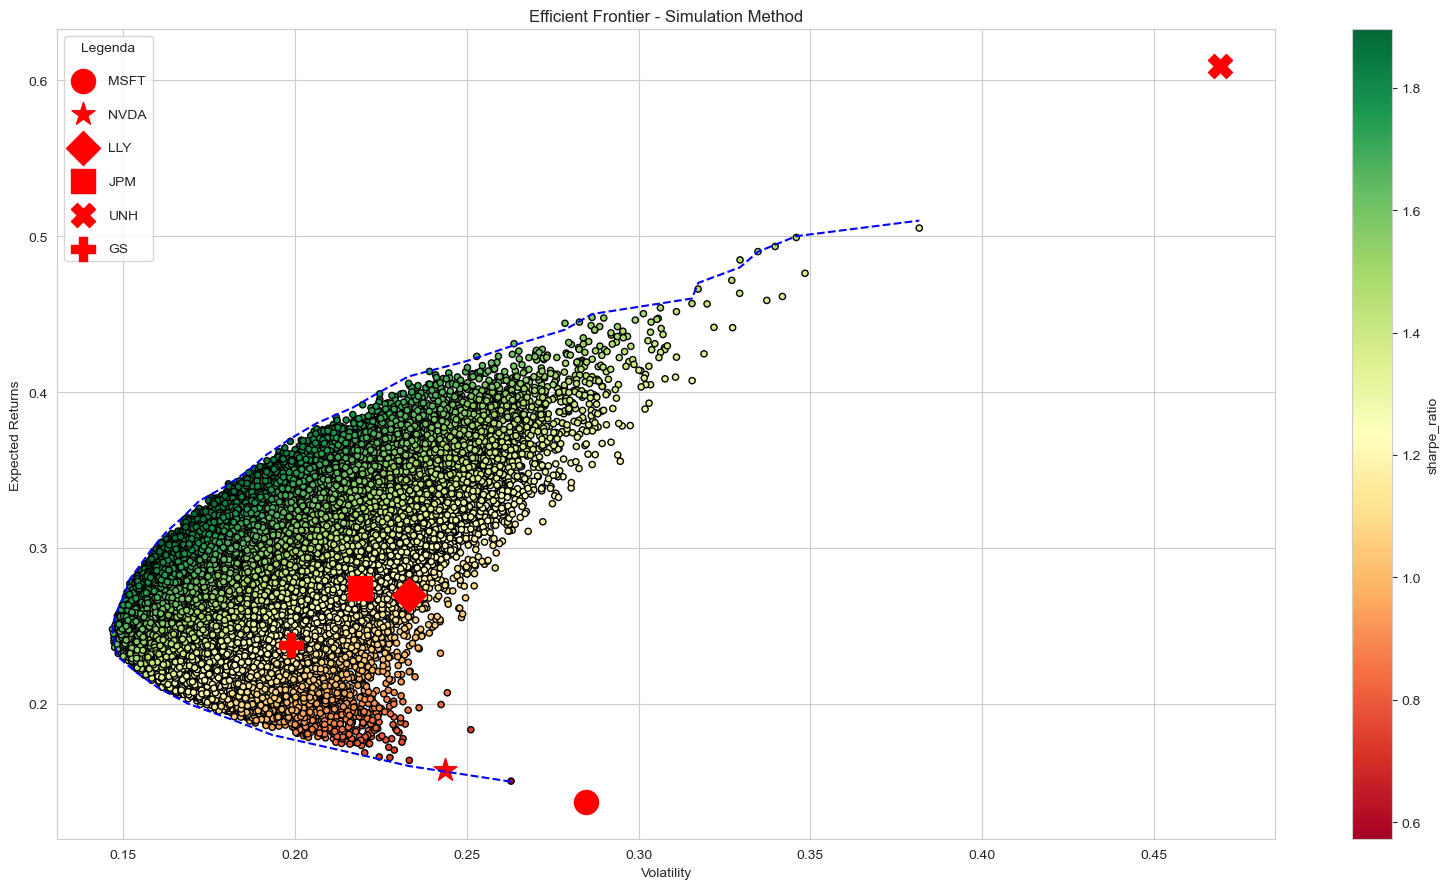

In [268]:
# stk_tickers = ['MSFT', 'NVDA', 'LLY', 'JPM', 'UNH', 'GS']
MARKS = ['o', '*', 'D', ',', 'X', 'P']
# Si inizializza una figura (fig) e un asse (ax) per il grafico.
fig, ax = plt.subplots(figsize=(16,9))
# grafico di dispersione dei portafogli
# x: volatilità (asse orizzontale) -> rischio di portafoglio
# y: rendimento atteso (asse verticale) -> rendimento atteso
# c: sharpe_ratio -> colore dei punti basato sullo sharpe ratio (da rosso a verde con la mappa dei color RdYlGn)
# edgecolor='black': i punti hanno un bordo nero per una migliore visibilità
# ax=ax: il grafico viene disegnato sugli assi già creati
portf_results_df.plot(kind='scatter', x='volatility', 
                      y='returns', c='sharpe_ratio',
                      cmap='RdYlGn', edgecolors='black', 
                      ax=ax)
# etichette e titolo del grafico
ax.set(xlabel='Volatility', 
       ylabel='Expected Returns', 
       title='Efficient Frontier - Simulation Method')
# disegno della frontiera efficiente
# b--: la frontiera efficiente viene tracciata con una linea blu tratteggiata
# portf_vol_ef: (asse X) rappresenta la volatilità minima per ogni rendimento
# portf_rtns_ef: (asse Y) rappresenta i rendimenti ottimali
ax.plot(portf_vol_ef, portf_rtns_ef, 'b--')
# aggiunta degli asset rischiosi
# x=np.sqrt(cov_mat.iloc[asset_index, asset_index]): la volatilità di ogni asset, ottenuta come radice quadrata della sua varianza nella matrice di covarianza
# y=avg_returns[asset_index]: rendimento atteso dell'asset
# market=MARKS[asset_index]: si assegna un marker diverso a ogni asset
# s=150: grandezza dei punti
# color='black': tutti gli asset vengono rappresentati in nero
# label=risky_asset[asset_index]: ogni asset viene etichettato per essere riconoscibile
for asset_index in range(n_assets):
    ax.scatter(x=np.sqrt(cov_mat.iloc[asset_index, asset_index]), 
                y=avg_returns[asset_index], 
                marker=MARKS[asset_index], 
                s=300, 
                color='red',
                label=stk_tickers[asset_index])
# viene aggiunta una legenda per distinguere i singoli asset
ax.legend(title='Legenda', labelspacing=1.5)
# miglioramento della disposizione del grafico
plt.tight_layout()
# visualizzazione del grafico
plt.show();


# i marker indicano se avessi un portafoglio investito solo con il singolo titolo dove si troverebbe esattamente
# colonna a destra del sharpe ratio indica solo il colore del pallino e più è verde più ha il sharpe ratio alto (tipo legenda)

In [269]:
# Ricerca del portafoglio con l'indice di Sharpe più alto
# trova l'indice della riga in portf_results_df con il valore massimo di sharpe ratio
max_sharpe_ind = np.argmax(portf_results_df.sharpe_ratio)
# seleziona il portafoglio corrispondente e lo salva in max_sharpe_portf_sm
max_sharpe_portf_sm = portf_results_df.loc[max_sharpe_ind]
max_sharpe_portf_sm

returns         0.318636
volatility      0.168113
sharpe_ratio    1.895369
Name: 50615, dtype: float64

In [270]:
# Ricerca del portafoglio con la volatilità più bassa
# trova l indice della riga con il valore minimo di volatilità
min_vol_ind = np.argmin(portf_results_df.volatility)
# seleziona il portafoglio corrispondente e lo salva in min_vol_portf_sm
# è il portafoglio meno rischioso, quindi è adatto agli investitori più avversi al rischio.
min_vol_portf_sm = portf_results_df.loc[min_vol_ind]
min_vol_portf_sm

returns         0.247778
volatility      0.146863
sharpe_ratio    1.687134
Name: 51441, dtype: float64

In [271]:
# Ricerca del portafoglio con la volatilità più bassa
# trova l indice della riga con il valore minimo di volatilità
min_vol_ind = np.argmin(portf_results_df.volatility)
# seleziona il portafoglio corrispondente e lo salva in min_vol_portf_sm
# è il portafoglio meno rischioso, quindi è adatto agli investitori più avversi al rischio.
min_vol_portf_sm = portf_results_df.loc[min_vol_ind]
min_vol_portf_sm

returns         0.247778
volatility      0.146863
sharpe_ratio    1.687134
Name: 51441, dtype: float64

In [272]:
print('Maximum Sharpe Ratio portfolio SM:')
print('Performance')
# stampa delle metriche di performance
# end='': l'output rimane sulla stessa riga (invece che andare a capo)
# flush=True: forza Python a scrivere immediatamente l'output senza aspettare che il buffer si riempia
for index, value in max_sharpe_portf_sm.items():
    print(f'{index}: {100 * value:.2f}% ', end="", flush=True)
print('\nrand_weights')
# stampa della distribuzione dei pesi
for x, y in zip(stk_tickers, rand_weights[max_sharpe_ind]):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

Maximum Sharpe Ratio portfolio SM:
Performance
returns: 31.86% volatility: 16.81% sharpe_ratio: 189.54% 
rand_weights
MSFT: 0.88% NVDA: 0.89% LLY: 36.09% JPM: 12.44% UNH: 17.84% GS: 31.86% 

In [273]:
rand_weights[max_sharpe_ind]

array([0.00884696, 0.00887121, 0.36086156, 0.12438326, 0.17839032,
       0.3186467 ])

In [274]:
print('Minimum Volatility portfolio SM:')
print('Performance')
for index, value in min_vol_portf_sm.items():
    print(f'{index}: {100 * value:.2f}% ', end="", flush=True)
print('\nrand_weights')
for x, y in zip(stk_tickers, rand_weights[np.argmin(portf_results_df.volatility)]):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

Minimum Volatility portfolio SM:
Performance
returns: 24.78% volatility: 14.69% sharpe_ratio: 168.71% 
rand_weights
MSFT: 0.65% NVDA: 11.06% LLY: 24.83% JPM: 27.56% UNH: 0.36% GS: 35.54% 

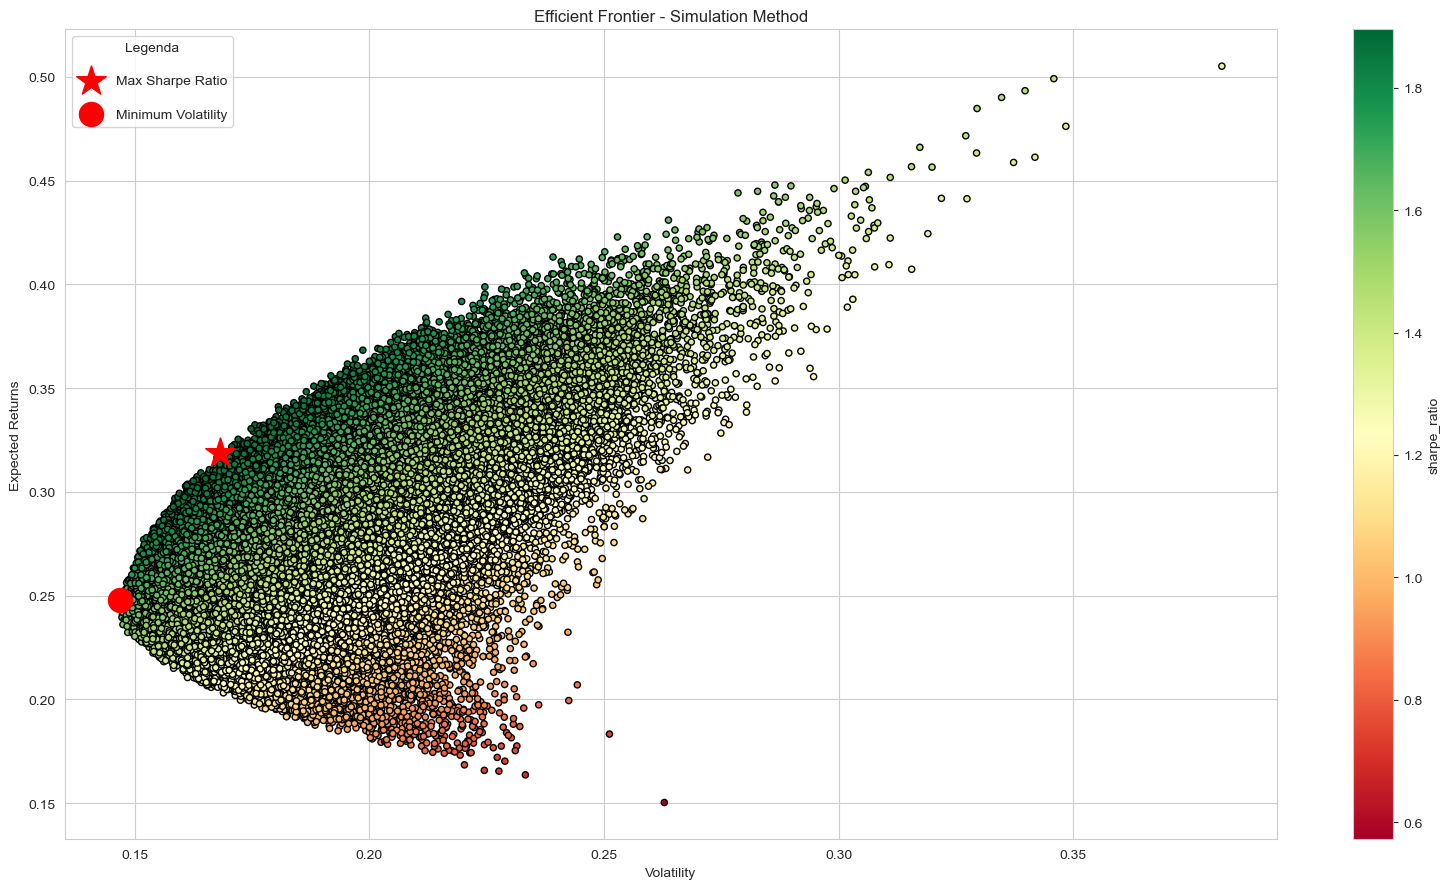

In [275]:
fig, ax = plt.subplots(figsize=(16,9))
# disegna il grafico a punti della dispersione della frontiera efficiente
portf_results_df.plot(kind='scatter', x='volatility', 
                      y='returns', c='sharpe_ratio',
                      cmap='RdYlGn', edgecolors='black', 
                      ax=ax)
# punto che rappresenta il portafoglio con il miglior compromesso rischio-rendimento (massimo Sharpe Ratio)
ax.scatter(x=max_sharpe_portf_sm.volatility, 
           y=max_sharpe_portf_sm.returns, 
           c='red', marker='*', 
           s=500, label='Max Sharpe Ratio')
# punto che rappresenta il portafoglio con la minima volatilità (meno rischioso)
ax.scatter(x=min_vol_portf_sm.volatility, 
           y=min_vol_portf_sm.returns, 
           c='red', marker='o', 
           s=300, label='Minimum Volatility')
ax.set(xlabel='Volatility', ylabel='Expected Returns', 
       title='Efficient Frontier - Simulation Method')
ax.legend(title='Legenda', labelspacing=1.5)

plt.tight_layout()

plt.show();

## metodo analitico (matematico)

In [277]:
# Calcolo del rendimento atteso del portafoglio
# w: sono i pesi degli asset
# avg_rtns: i rendimenti medi
def get_portf_rtn(w, avg_rtns):
    return np.sum(avg_rtns * w)
# Calcolo della volatilità (rischio) del portafoglio
# cov_mat: matrice di covarianza
def get_portf_vol(w, avg_rtns, cov_mat):
    return np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))

In [278]:
# Restituisce una lista di portafogli ottimizzati (uno per ogni rendimento target in rtns_range) dove ogni portafoglio contiene:
# pesi ottimali
# volatilità risultante
# rendimento atteso
# informazioni sullo stato dell'ottimizzazione
def get_efficient_frontier(avg_rtns, cov_mat, rtns_range):
    
    efficient_portfolios = []
    
    n_assets = len(avg_returns) # numero degli asset
    args = (avg_returns, cov_mat) # prepara gli argomenti per l'ottimizzazione
    bounds = tuple((0,1) for asset in range(n_assets)) # per ogni asset nel portafoglio crea una tupla(0,1)
    initial_guess = n_assets * [1. / n_assets] # assegna a ogni asset lo stesso peso [equal weight]
    
    for ret in rtns_range:
        # primo vincolo: rendimento di portafoglio = rendimento target（ret)
        # secondo vincolo: somma dei pesi = 1 (investimento completo)
        constraints = ({'type': 'eq', 
                        'fun': lambda x: get_portf_rtn(x, avg_rtns) - ret},
                       {'type': 'eq', 
                        'fun': lambda x: np.sum(x) - 1})
        # minimizza la volatilità (get_portf_vol) per il rendimento target
        # parte da pesi uguali (initial_guess)
        # rispetta i limiti (no pesi negativi, nessun peso > 1)
        efficient_portfolio = sco.minimize(get_portf_vol, initial_guess, 
                                           args=args, method='SLSQP', 
                                           constraints=constraints,
                                           bounds=bounds)
        # lo aggiunge nella lista
        efficient_portfolios.append(efficient_portfolio)
    
    return efficient_portfolios

# crea un array di 200 valori equalmente distribuiti tra -0.22 e 0.32
rtns_range = np.linspace(-0.22, 0.32, 200)

# crea tutti i portafogli ottimizzati
# è una lista di dizionari (uno per ogni portafoglio ottimizzato)
efficient_portfolios = get_efficient_frontier(avg_returns, 
                                              cov_mat, 
                                              rtns_range)
# list comprehension estrae i valori di volatilità (deviazione standard) da una lista di portafogli ottimizzati
# x['fun']: accede al valore della funzione obiettivo minimizzata
# dato che abbiamo minimizzato get_portf_vol(): questo è il valore della volatilità del portafoglio
# estrae in tutti i dizionari (x in efficient_portfolios) il valore della volatilità (x['fun'])
vols_range = [x['fun'] for x in efficient_portfolios]

In [279]:
# Portafoglio con minima volatilità
min_vol_ind = np.argmin(vols_range)

min_vol_portf_sa_rtn = rtns_range[min_vol_ind]
min_vol_portf_sa_vol = efficient_portfolios[min_vol_ind]['fun']

min_vol_portf_sa = {'Return': min_vol_portf_sa_rtn,
                 'Volatility': min_vol_portf_sa_vol,
                 'Sharpe Ratio': (min_vol_portf_sa_rtn / 
                                  min_vol_portf_sa_vol)}

min_vol_portf_sa

{'Return': 0.24130653266331661,
 'Volatility': 0.14617681574321242,
 'Sharpe Ratio': 1.6507852591837666}

In [280]:
# Sommario dei risultati
print('Minimum Volatility portfolio SA:')
print('Performance')

for index, value in min_vol_portf_sa.items():
    print(f'{index}: {100 * value:.2f}% ', end="", flush=True)

# pesi di ogni asset
print('\nWeights')
for x, y in zip(stk_tickers, efficient_portfolios[min_vol_ind]['x']):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

Minimum Volatility portfolio SA:
Performance
Return: 24.13% Volatility: 14.62% Sharpe Ratio: 165.08% 
Weights
MSFT: 0.00% NVDA: 17.34% LLY: 25.71% JPM: 24.72% UNH: 0.00% GS: 32.22% 

In [281]:
# Funzione obiettivo
def neg_sharpe_ratio(w, avg_rtns, cov_mat, rf_rate):
    portf_returns = np.sum(avg_rtns * w)
    portf_volatility = np.sqrt(np.dot(w.T, np.dot(cov_mat, w)))
    portf_sharpe_ratio = (portf_returns - rf_rate) / portf_volatility
    return -portf_sharpe_ratio

In [282]:
# Ricerca del portafoglio ottimale
n_assets = len(avg_returns)
RF_RATE = 0

# argomenti da minimizzare
args = (avg_returns, cov_mat, RF_RATE)
# somma dei pesi deve essere uguale a 1
constraints = ({'type': 'eq', 
                'fun': lambda x: np.sum(x) - 1})
# limiti dei pesi tra 0 e 1
bounds = tuple((0,1) for asset in range(n_assets))
# pesi di ogni asset in modo equo
initial_guess = n_assets * [1. / n_assets]

# minimizziamo lo sharpe ratio perchè esiste solo la funzione minimize e non una funzione per massimizzare
# Massimizzare lo Sharpe Ratio = Minimizzare lo Sharpe Ratio negativo
max_sharpe_portf_sa = sco.minimize(neg_sharpe_ratio, 
                                x0=initial_guess, 
                                args=args,
                                method='SLSQP', 
                                bounds=bounds, 
                                constraints=constraints)

max_sharpe_portf_sa_w = max_sharpe_portf_sa['x'] 
max_sharpe_portf_sa = {'Return': get_portf_rtn(max_sharpe_portf_sa_w, 
                                            avg_returns),
                    'Volatility': get_portf_vol(max_sharpe_portf_sa_w, 
                                                avg_returns, 
                                                cov_mat),
                    'Sharpe Ratio': -max_sharpe_portf_sa['fun']}
max_sharpe_portf_sa

{'Return': 0.3257475876468026,
 'Volatility': 0.17097645740712522,
 'Sharpe Ratio': 1.9052189557954164}

In [283]:
print('Maximum Sharpe Ratio portfolio SA:')
print('Performance')

for index, value in max_sharpe_portf_sa.items():
    print(f'{index}: {100 * value:.2f}% ', end="", flush=True)

print('\nWeights')
for x, y in zip(stk_tickers, max_sharpe_portf_sa_w):
    print(f'{x}: {100*y:.2f}% ', end="", flush=True)

Maximum Sharpe Ratio portfolio SA:
Performance
Return: 32.57% Volatility: 17.10% Sharpe Ratio: 190.52% 
Weights
MSFT: 0.00% NVDA: 0.00% LLY: 34.87% JPM: 13.25% UNH: 19.35% GS: 32.54% 

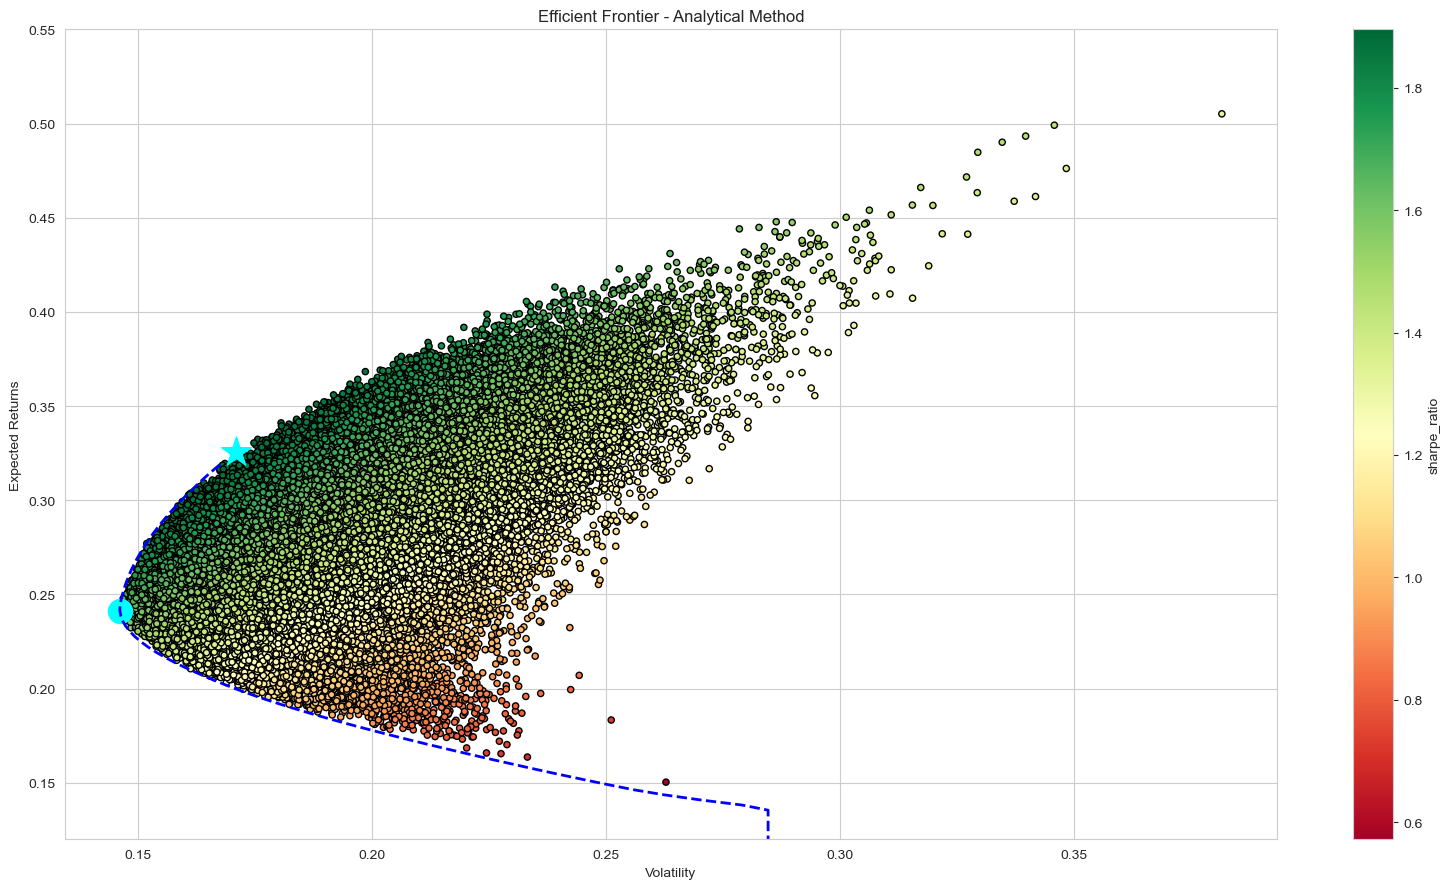

In [284]:
fig, ax = plt.subplots(figsize=(16,9))
portf_results_df.plot(kind='scatter', x='volatility', 
                      y='returns', c='sharpe_ratio',
                      cmap='RdYlGn', edgecolors='black', 
                      ax=ax)
ax.plot(vols_range, rtns_range, 'b--', linewidth=2)
# punto che rappresenta il portafoglio con il miglior compromesso rischio-rendimento (massimo Sharpe Ratio)
ax.scatter(x=max_sharpe_portf_sa['Volatility'], 
           y=max_sharpe_portf_sa['Return'], 
           c='aqua', marker='*', 
           s=500, label='Max Sharpe Ratio')
# punto che rappresenta il portafoglio con la minima volatilità (meno rischioso)
ax.scatter(x=min_vol_portf_sa['Volatility'], 
           y=min_vol_portf_sa['Return'], 
           c='aqua', marker='o', 
           s=300, label='Minimum Volatility')
ax.set(xlabel='Volatility', 
       ylabel='Expected Returns', 
       title='Efficient Frontier - Analytical Method')

plt.ylim(0.12, 0.55)
plt.tight_layout()
plt.show();

In [285]:
# .values: converte una Series/DataFrame in array NumPy
# sono già in array NumPy
# avg_returns = avg_returns.values
# cov_mat = cov_mat.values

# crea una variabile di ottimizzazione per i pesi del portafoglio
# n_assets: è il numero di asset nel portafoglio
weights = cp.Variable(n_assets)
# Parametro di Avversione al Rischio
# nonneg=True: impone che sia non negativo (y >= 0)
gamma = cp.Parameter(nonneg=True)
# Rendimento Atteso del portafoglio
# calcola il rendimento atteso come prodotto scalare tra avg_returns e weights
portf_rtn_cvx = avg_returns.to_numpy() @ weights
# Rischio (Varianza) del Portafoglio
# calcola la varianza del portafoglio usando la forma quadratica
portf_vol_cvx = cp.quad_form(weights, cov_mat)
# Funzione Obiettivo
# Massimizza la differenza tra rendimento e rischio ponderato
objective_function = cp.Maximize(portf_rtn_cvx - gamma * portf_vol_cvx)
# Vincoli
# cp.sum(weights) == 1: vincolo di budget (pesi sommano a 1)
# weights >= 0: vincolo di non-negatività
problem = cp.Problem(objective_function, 
                     [cp.sum(weights) == 1, weights >= 0])

'''
Interpretazione Economica
Questo problema rappresenta l'ottimizzazione di portafoglio secondo la teoria di Markowitz:

Per ogni valore di γ otteniamo un portafoglio efficiente

Variando γ possiamo tracciare l'intera frontiera efficiente

γ controlla il trade-off rischio-rendimento:

γ piccolo → più aggressivo (più rendimento, più rischio)

γ grande → più conservativo (meno rischio,
meno rendimento)
''';

In [286]:
N_POINTS = 25
portf_rtn_cvx_ef = np.zeros(N_POINTS) # Array per i rendimenti
portf_vol_cvx_ef = np.zeros(N_POINTS) # Array per le volatilità
weights_ef = [] # Lista per i pesi ottimali
gamma_range = np.logspace(-3, 3, num=N_POINTS) # crea valori distribuiti di Y (Gamma) su scala Logaritmica da 10^-3 a 10^3

for i in range(N_POINTS):
    gamma.value = gamma_range[i] # imposta il valore corrente di gamma
    problem.solve() # risolve il problema di ottimizzazione
    
    # Salva i risultati
    portf_vol_cvx_ef[i] = cp.sqrt(portf_vol_cvx).value # Deviazione standard
    portf_rtn_cvx_ef[i] = portf_rtn_cvx.value # Rendimento atteso
    weights_ef.append(weights.value) # Pesi ottimali

# Variazione di γ:
# γ piccolo → più peso al rendimento (portafogli aggressivi)
# γ grande → più peso al rischio (portafogli conservativi)

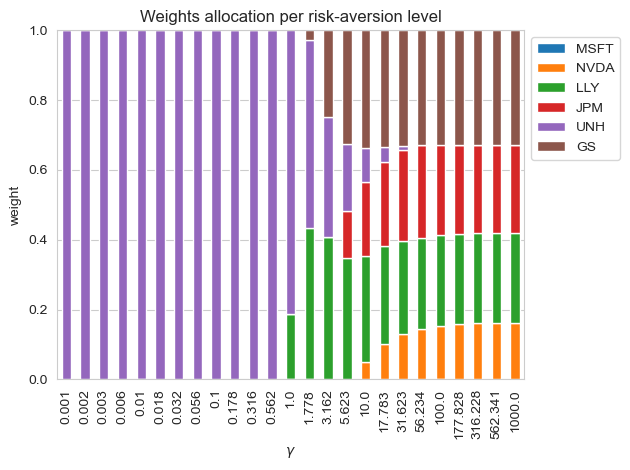

In [287]:
weights_df = pd.DataFrame(weights_ef, 
                          columns=stk_tickers, 
                          index=np.round(gamma_range, 3))
ax = weights_df.plot(kind='bar', stacked=True) 
ax.set(title='Weights allocation per risk-aversion level',
       xlabel=r'$\gamma$', 
       ylabel='weight')
ax.legend(bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show();

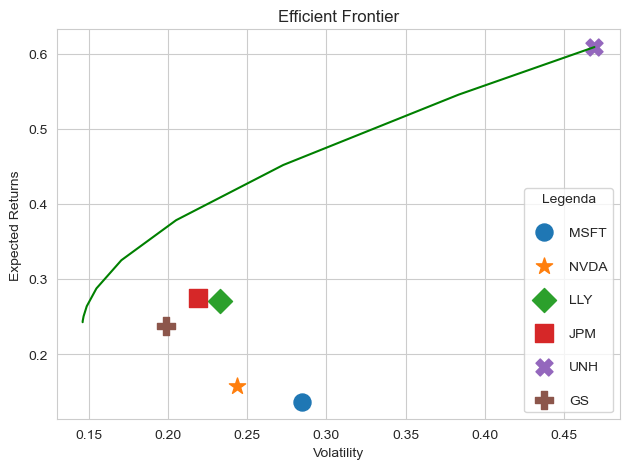

In [288]:
#MARKS = ['o', 'X', 'd', '*']

fig, ax = plt.subplots()
ax.plot(portf_vol_cvx_ef, portf_rtn_cvx_ef, 'g-')
for asset_index in range(n_assets):
     # x=np.sqrt(cov_mat[asset_index, asset_index]: calcola la deviazione standard, cioè la volatilità dell'asset
     ax.scatter(x=np.sqrt(cov_mat.iloc[asset_index, asset_index]), 
                 y=avg_returns[asset_index], 
                 marker=MARKS[asset_index], 
                 label=stk_tickers[asset_index],
                 s=150)
ax.set(title='Efficient Frontier',
       xlabel='Volatility', 
       ylabel='Expected Returns', )
ax.legend(title='Legenda', labelspacing=1.5)

plt.tight_layout()
plt.grid(True)
plt.show();

In [289]:
def beta_portfolio(indice, rs_mensili, weights):
    ri = indice['Close'].pct_change()
    ri_mensili = (1 + ri).resample('ME').prod() - 1
    portfolio_returns = (rs_mensili[:periodo]).dot(weights)
    X = pd.concat([ri_mensili[:periodo], portfolio_returns], axis=1)
    covariance = X.cov().iloc[0,1]
    benchmark_variance = X['^GSPC'].var()
    beta = covariance / benchmark_variance
    return beta

In [347]:
best_beta_portfoglio_sm = beta_portfolio(indice, rs_mensili, rand_weights[max_sharpe_ind])
print(f"beta del miglior portaglio metodo di simulazione: {best_beta_portfoglio_sm:.5f}")

beta del miglior portaglio metodo di simulazione: 0.79958


In [349]:
best_beta_portfoglio_am = beta_portfolio(indice, rs_mensili, max_sharpe_portf_sa_w)
print(f"beta del miglior portaglio metodo analitico: {best_beta_portfoglio_am:.5f}")

beta del miglior portaglio metodo analitico: 0.81238


In [780]:
n_assets

6

In [320]:
# Dati di esempio (sostituisci con i tuoi)
portf_returns_sm = (rs_mensili[:periodo]).dot(rand_weights[max_sharpe_ind])
portf_returns_am = (rs_mensili[:periodo]).dot(max_sharpe_portf_sa_w)

# 1. Pesi equiponderati
equal_weights = np.array([1/n_assets] * n_assets)

# 2. Calcolo rendimenti
equal_returns = (rs_mensili[:periodo]).dot(equal_weights)

                       Portfolio_sm Portfolio_am Portfolio_Equiponderato
Rendimento medio annuo       31.86%       32.57%                  28.10%
Volatilità annua             16.81%       17.10%                  18.26%
Sharpe Ratio                   1.90         1.91                    1.54


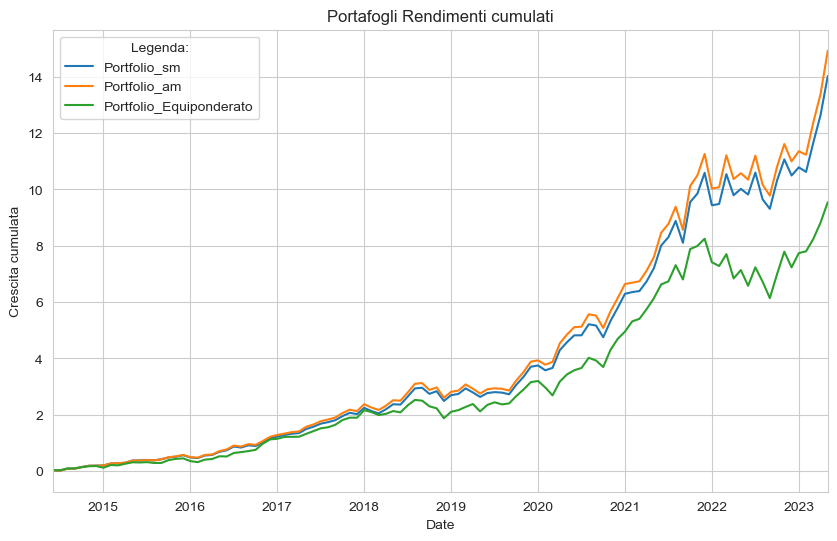

In [322]:
# 3. Statistiche
def portfolio_stats(returns, name):
    mean_return = returns.mean() * 12
    volatility = returns.std() * np.sqrt(12)
    sharpe_ratio = mean_return / volatility
    return pd.Series({
        'Rendimento medio annuo': f"{mean_return*100:.2f}%",
        'Volatilità annua': f"{volatility*100:.2f}%",
        'Sharpe Ratio': f"{sharpe_ratio:.2f}"
    }, name=name)

comparison = pd.concat([
    portfolio_stats(portf_returns_sm, 'Portfolio_sm'),
    portfolio_stats(portf_returns_am, 'Portfolio_am'),
    portfolio_stats(equal_returns, 'Portfolio_Equiponderato')
], axis=1)

print(comparison)

# 4. Grafico
plt.figure(figsize=(10, 6))
( (1 + portf_returns_sm).cumprod() - 1 ).plot(label='Portfolio_sm')
( (1 + portf_returns_am).cumprod() - 1 ).plot(label='Portfolio_am')
( (1 + equal_returns).cumprod() - 1 ).plot(label='Portfolio_Equiponderato')
plt.title('Portafogli Rendimenti cumulati')
plt.ylabel('Crescita cumulata')
plt.legend(title='Legenda:')
plt.show();